# `Machine Learning project (group SEA, 13) -  Alkemy AI Productivity`
### **What happens to margins when AI enters business workflows?**

## Import of the libraries 

In [256]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import missingno as msno
from IPython.display import display, Markdown
from itertools import zip_longest
import warnings
from scipy.stats import mannwhitneyu
from scipy import stats

In [257]:
warnings.filterwarnings('ignore')

## Upload of the dataset

In [258]:
HERE = os.path.abspath('')      
DATA_DIR = os.path.join(HERE, "data")
PATH = os.path.join(DATA_DIR, "ai_productivity_dataset_final.csv")

In [259]:
df_productivity = pd.read_csv(PATH)

## `First EDA`

### Dataset Overview and Descriptive Statistics
The dataset contains **3,248 observations** and **34 variables**, each observation representing a single task performed within a business workflow. The unit of analysis is at the task level, enabling a granular assessment of operational performance.
#### Data Types
Based on the info and exploratory steps executed, the 34 columns are categorized as follows:
- **15 Numerical variables** (e.g., `task_complexity_score`, `hours_spent`, `revenue`, `profit`)
- **18 Categorical variables** (e.g., `task_id`, `client`, `seniority`, `task_type`)
- **1 Boolean variable** (`ai_assisted`)                    

The variables encompass multiple dimensions of the workflow:
- **Operational efficiency**: `hours_spent` (mean: 13.06, max: 263.6), `billable_hours`, `sla_days` (mean: 5.01)
- **AI adoption**: `ai_usage_pct` (ranging from 0% to 93%), `ai_assisted`
- **Quality and process performance**: `revisions` (mean: 3.0), `errors` (mean: 1.01, max: 7), `rework_hours` (mean: 2.44, max: 57.5)
- **Economic outcomes**: `revenue` (mean: 1,120), `cost` (mean: 771), `profit`
---
### Descriptive Statistics Highlights
The summary statistics provide initial insights into the distribution and variability of key variables:
#### 1) Profit and Economic Outcomes
The average **profit** is approximately 349, while the median is lower (around 255), indicating a right-skewed distribution. The presence of strongly negative values (minimum ≈ -8510) suggests that some tasks generate substantial losses, while others are highly lucrative (maximum ≈ 14006). A high standard deviation (≈ 888) reflects significant variability in profitability across tasks. Similarly, **revenue** is heavily right-skewed with a maximum of nearly 15,000 compared to a mean of 1,120.
#### 2) AI Usage
The average **AI usage** is approximately 36% (`ai_usage_pct`), missing in some records, with existing values ranging strictly from 0% to 93%. This continuous spectrum indicates that AI is not uniformly adopted across tasks but varies significantly in intensity. This enables the analysis of non-linear relationships and the identification of potential threshold effects.
#### 3) Time and Efficiency
The average **time spent** per task is roughly 13 hours, with a median of about 11 hours. Extreme outliers are present (maximum ≈ 263 hours), suggesting the existence of highly complex or delayed tasks. In addition, ~40% of the recorded tasks incurred an **SLA breach** (mean `sla_breach`: 0.398).
#### 4) Rework and Quality Performance
The average **rework time** is approximately 2.4 hours, but severely right-skewed with a maximum value exceeding 57 hours. This suggests that a small subset of tasks generates disproportionately high levels of rework, severely impacting efficiency. Task complexity scores and brief quality scores both hover around a mean of 3 on a 1-5 scale, indicating moderate difficulty and baseline quality on average.

---
### Data Quality Considerations
Several variables contain missing values. In 3,248 total rows, columns like `ai_usage_pct` (3,104 non-null), `rework_hours` (3,176 non-null), `billable_hours` (3,166 non-null), `outcome_score` (3,115 non-null), and `brief_quality_score` (3,179 non-null) show gaps. Rather than being solely technical issues, these missing entries may reflect real-world data collection limitations, unrecorded workflows, or process inefficiencies requiring careful imputation.

---
### Implications for Further Analysis
This descriptive phase highlights the following key directions:
1. **Heterogeneous Profitability**: The extreme variability in profit and rework hours motivates investigating exactly which conditions (e.g., `client_tier`, `task_type`) lead to losses versus high margins.
2. **AI Impact on Efficiency**: AI usage is recorded as a continuous percentage, allowing for deeply exploring its linear or non-linear effects on completion time (`hours_spent`) and quality (`errors`, `rework_hours`).
3. **Quality Instability**: Rework and SLA breaches are concentrated in specific tasks, representing clear points of leverage for process optimization.

In [260]:
print("Dataset shape:", df_productivity.shape)

Dataset shape: (3248, 34)


In [261]:
df_productivity["scope_change_flag"].unique()

array([0, 1])

In [262]:
print("--- INFO ---")
df_productivity.info()

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 3248 entries, 0 to 3247
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   task_id                3248 non-null   str    
 1   client                 3248 non-null   str    
 2   project_id             3248 non-null   str    
 3   client_tier            3248 non-null   str    
 4   team                   3248 non-null   str    
 5   task_type              3248 non-null   str    
 6   seniority              3248 non-null   str    
 7   task_complexity_score  3248 non-null   int64  
 8   brief_quality_score    3179 non-null   float64
 9   deadline_pressure      3248 non-null   str    
 10  scope_change_flag      3248 non-null   int64  
 11  pricing_model          3248 non-null   str    
 12  created_at             3248 non-null   str    
 13  delivered_at           3210 non-null   str    
 14  sla_days               3212 non-null   float64
 15  sl

In [263]:
num_cols = df_productivity.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_productivity.select_dtypes(include=['object', 'string']).columns.tolist()
bool_cols = df_productivity.select_dtypes(include=['bool', 'boolean']).columns.tolist()

# Create a Markdown table layout
md_text = f"""
| 🔢 Numerical ({len(num_cols)}) | 🔠 Categorical ({len(cat_cols)}) | 🔘 Boolean ({len(bool_cols)}) |
| :--- | :--- | :--- |
"""

# Zip all THREE lists together
for num, cat, b_col in zip_longest(num_cols, cat_cols, bool_cols, fillvalue=""):
    md_text += f"| {num} | {cat} | {b_col} |\n"

# Display the table
print("Columns Types:")
display(Markdown(md_text))

Columns Types:



| 🔢 Numerical (15) | 🔠 Categorical (18) | 🔘 Boolean (1) |
| :--- | :--- | :--- |
| task_complexity_score | task_id | ai_assisted |
| brief_quality_score | client |  |
| scope_change_flag | project_id |  |
| sla_days | client_tier |  |
| sla_breach | team |  |
| hours_spent | task_type |  |
| billable_hours | seniority |  |
| ai_usage_pct | deadline_pressure |  |
| revisions | pricing_model |  |
| errors | created_at |  |
| rework_hours | delivered_at |  |
| outcome_score | created_by |  |
| revenue | updated_at |  |
| cost | task_status |  |
| profit | workflow_stage |  |
|  | jira_ticket |  |
|  | legacy_ai_flag |  |
|  | content_version |  |


In [264]:
print("--- DESCRIPTIVE STATISTICS  ---")
df_productivity.describe()

--- DESCRIPTIVE STATISTICS  ---


,task_complexity_score,brief_quality_score,scope_change_flag,sla_days,sla_breach,hours_spent,billable_hours,ai_usage_pct,revisions,errors,rework_hours,outcome_score,revenue,cost,profit
count,3248.000000,3179.000000,3248.000000,3212.000000,3248.000000,3248.00000,3166.000000,3104.000000,3248.000000,3248.000000,3176.000000,3115.000000,3248.000000,3248.000000,3248.000000
mean,2.868842,3.183391,0.139163,5.012765,0.398091,13.05551,8.431563,0.361717,3.007697,1.014163,2.437543,68.856918,1120.571260,771.308146,349.263114
std,1.196459,1.211712,0.346169,2.520330,0.489580,11.55750,4.783216,0.199391,1.804829,1.042868,2.911421,12.642211,841.649433,584.269354,888.072715
min,1.000000,1.000000,0.000000,2.000000,0.000000,0.02000,-1.900000,0.000000,0.000000,0.000000,0.000000,9.000000,45.000000,77.850000,-8510.549511
25%,2.000000,2.000000,0.000000,3.000000,0.000000,7.91000,5.080000,0.200000,2.000000,0.000000,1.110000,60.870000,646.312500,440.805000,-2.610000
50%,3.000000,3.000000,0.000000,5.000000,0.000000,11.11500,7.535000,0.340000,3.000000,1.000000,1.810000,69.400000,966.430000,649.065000,254.645000
75%,4.000000,4.000000,0.000000,7.000000,1.000000,15.34500,10.687500,0.500000,4.000000,2.000000,2.950000,77.610000,1364.700000,941.145000,590.400000
max,5.000000,5.000000,1.000000,10.000000,1.000000,263.60018,47.020000,0.930000,11.000000,7.000000,57.517012,100.000000,14927.204324,9409.639511,14006.644324


#### Variables' Distribution

#### 1) Numerical variables:

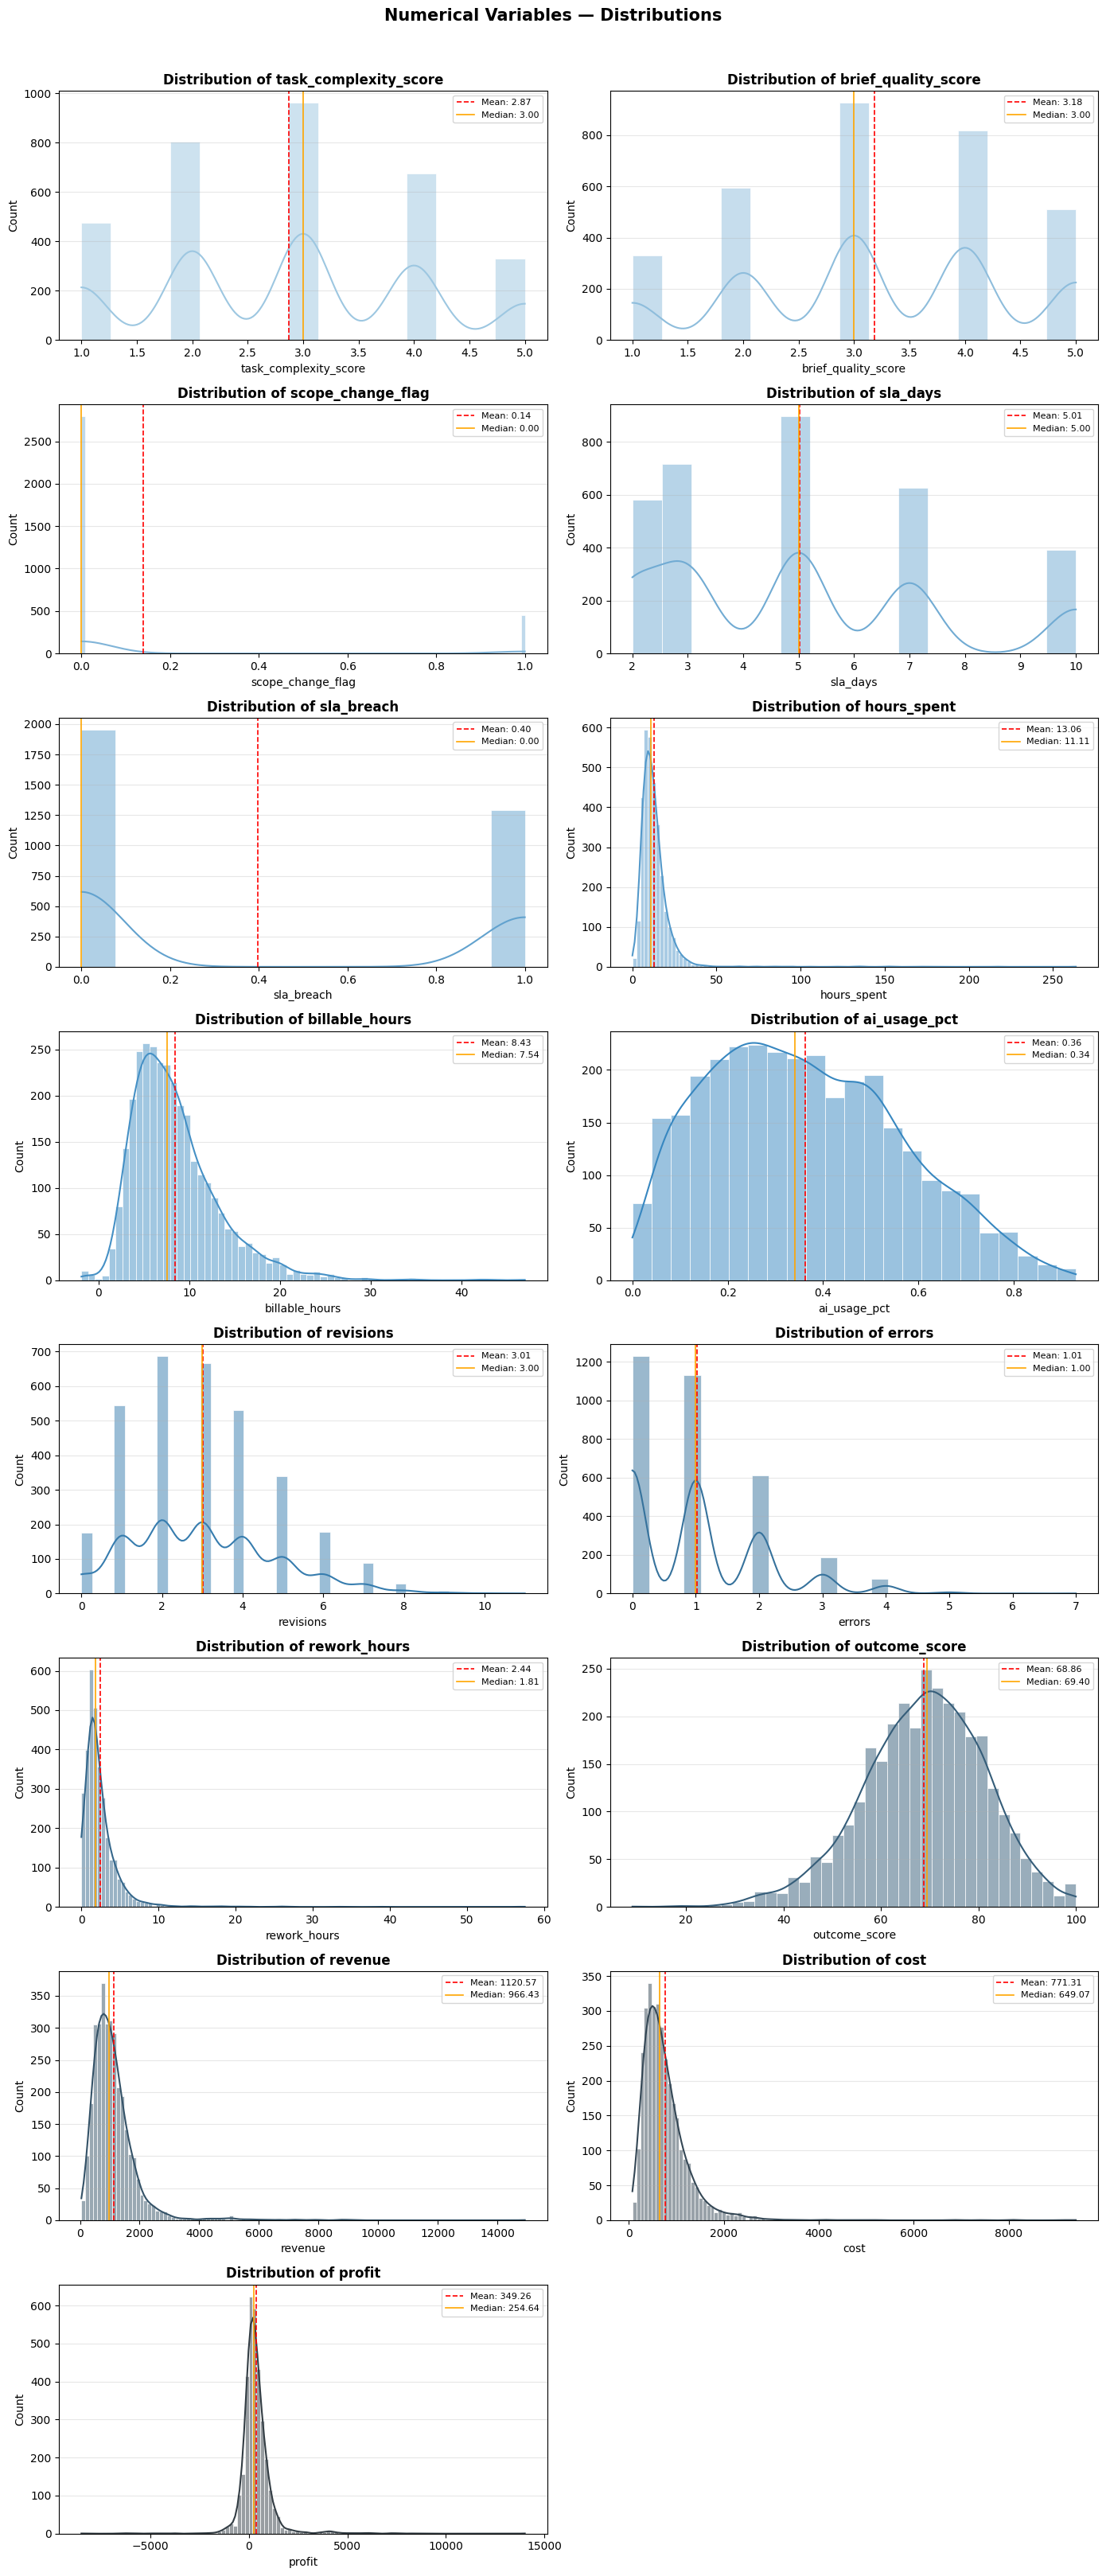

In [265]:
n_cols = 2
n_rows = (len(num_cols) + 1) // 2 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten()

palette = sns.color_palette("Blues_d", len(num_cols))  # Gradient palette

for i, col in enumerate(num_cols):
    ax = axes[i]
    
    sns.histplot(
        df_productivity[col],
        kde=True,
        color=palette[i],
        ax=ax,
        edgecolor='white',
        linewidth=0.5
    )
    
    # Vertical lines for mean and median
    mean_val = df_productivity[col].mean()
    median_val = df_productivity[col].median()
    ax.axvline(mean_val,   color='red',    linestyle='--', linewidth=1.2, label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color='orange', linestyle='-',  linewidth=1.2, label=f'Median: {median_val:.2f}')
    
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

# Hide any unused axes (when len(num_cols) is odd)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Variables — Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()


#### 2) Categorical & Boolean Variables

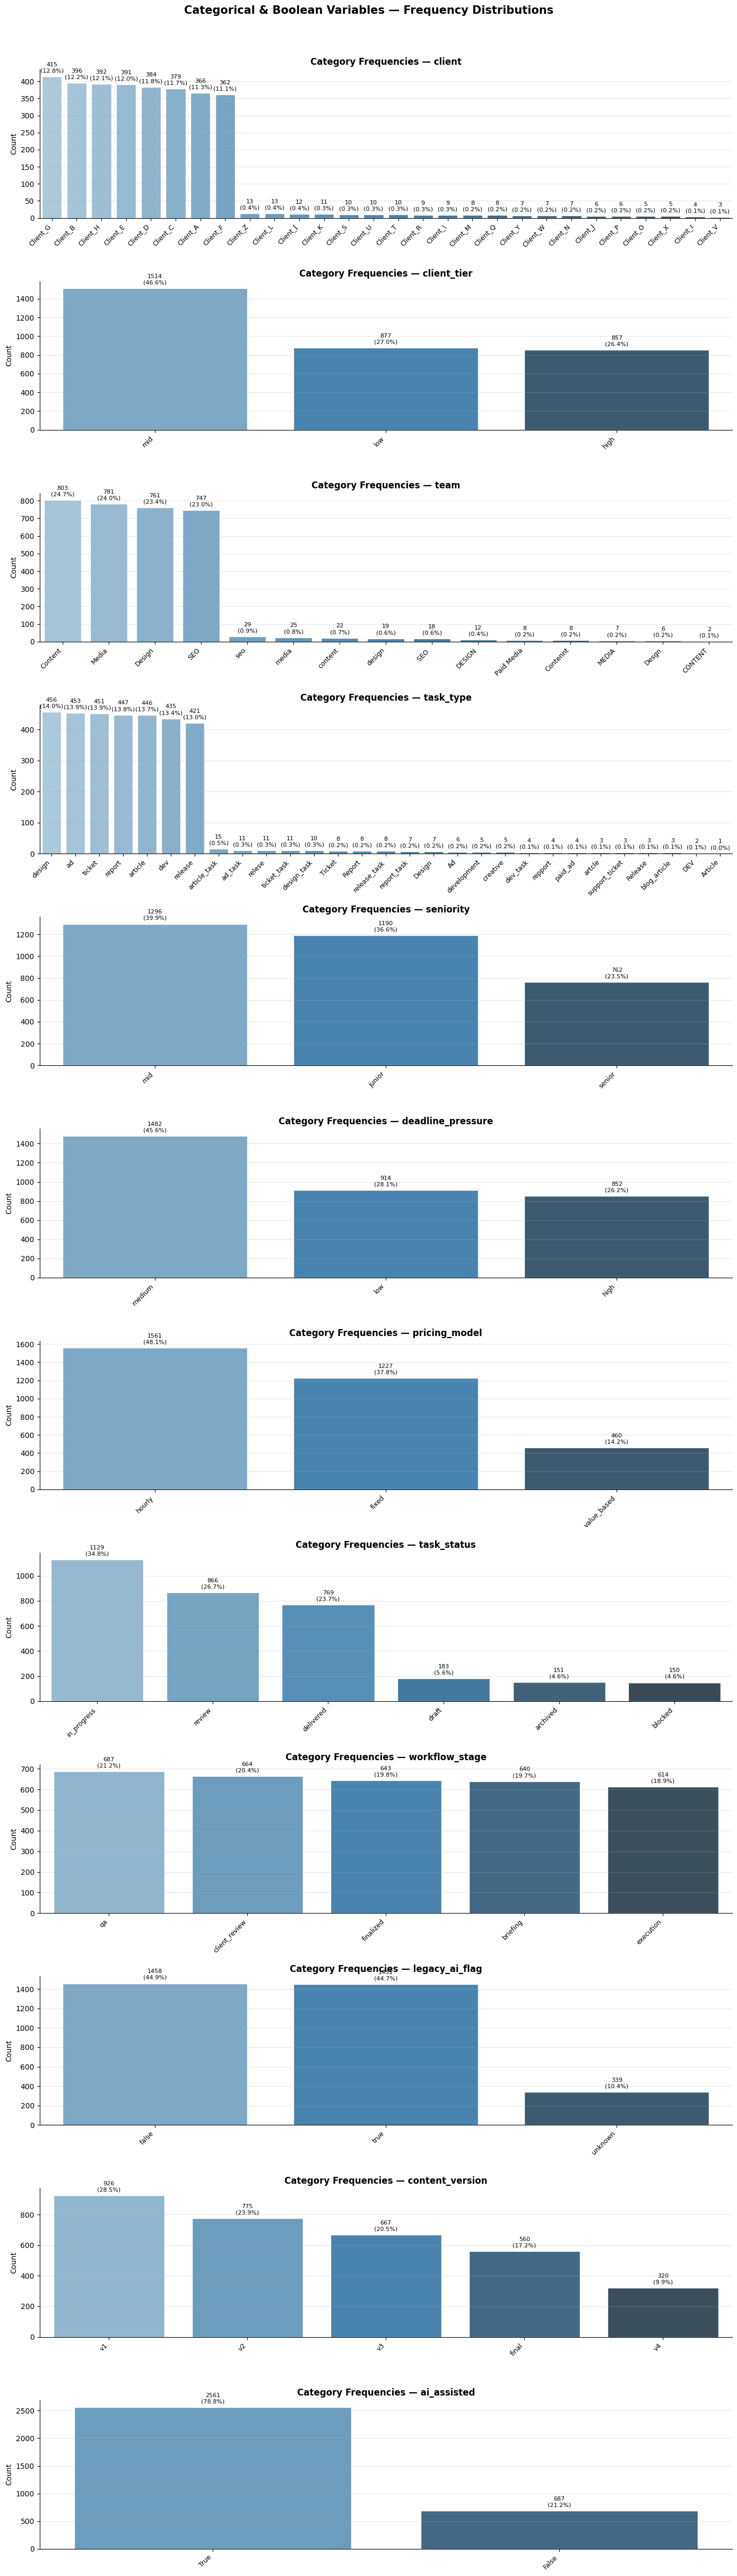

In [266]:
exclude_categories = ["task_id", "project_id", "created_at", "delivered_at", "created_by", "updated_at", "jira_ticket"]
cat_cols_filtered = [col for col in cat_cols if col not in exclude_categories]

cols_to_plot = cat_cols_filtered + bool_cols

fig, axes = plt.subplots(len(cols_to_plot), 1, figsize=(14, 4 * len(cols_to_plot)))
sns.despine()

for i, col in enumerate(cols_to_plot):
    ax = axes[i]

    # Build counts
    counts = (
        df_productivity[col]
        .value_counts(dropna=True)          
        .reset_index()
    )

    # Plot as barplot 
    sns.barplot(
        data=counts,
        x=col,
        y='count',
        palette='Blues_d',
        order=counts[col],          # Sorted by frequency (value_counts output)
        ax=ax,
        edgecolor='white',
    )

    # Annotate each bar with count + percentage
    total = counts['count'].sum()
    for bar in ax.patches:
        height = bar.get_height()
        pct = height / total * 100
        ax.annotate(
            f'{int(height)}\n({pct:.1f}%)',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 4),
            textcoords='offset points',
            ha='center', va='bottom',
            fontsize=8
        )

    ax.set_title(f'Category Frequencies — {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Count', fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.set_xticklabels(ax.get_xticklabels(), ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

# Hide any trailing empty axes 
for j in range(len(cols_to_plot), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical & Boolean Variables — Frequency Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()


### Data Cleaning Summary (Duplicates & Feature Engineering)

Based on the execution of the previous sections, the following data preprocessing and cleaning steps were implemented to ensure consistency and reliability:

#### 1. Deduplication
We identified **48 duplicate observations** sharing the same `task_id`. To resolve this natively, the records were sorted by their `updated_at` timestamp, and the most recent entry was preserved (guaranteeing the latest task status is used). Post-processing confirmed that 0 duplicates remain.

#### 2. Normalization of the `team` and `task_type` Columns
Both columns contained inconsistent casing, formatting variants, and typos. We standardized text by stripping whitespace, lowercasing values, and applying explicit mapping dictionaries to consolidate variants into canonical labels.

For `team`, the cleaned output is exactly **4 categories** with a balanced distribution:
- **Content**: 827 tasks
- **Media**: 805 tasks
- **Design**: 790 tasks
- **SEO**: 778 tasks

For `task_type`, multiple variants (e.g., `ad_task`, `blog_article`, `support_ticket`) and typos (e.g., `artcle`, `relese`, `repport`) were merged into **7 canonical categories**:
- **Ad**
- **Article**
- **Design**
- **Development**
- **Release**
- **Report**
- **Ticket**

This normalization step ensures category consistency for downstream grouped analyses and segmented heatmaps.

#### 3. Date Parsing & Task Duration Calculation
The timestamps `created_at` and `delivered_at` were successfully cast to datetime objects (resulting in 0 missing values for creation dates and 38 `NaT` for delivery).
A new engineered feature, **`duration_days`**, was created to track end-to-end task time. During validity checks, **14 negative durations** were discovered, likely representing data entry errors or misaligned timestamps, and were appropriately replaced with `NaN`. The cleaned `duration_days` feature now correctly spans from 0 to 10 days, with a mean task duration of 4.5 days.

#### 4. Standardizing the `legacy_ai_flag`
This column originally consisted of lowercase, capitalized, and 'unknown' string values. It was standardized into a clean numeric format (1.0 for True, 0.0 for False). The 'unknown' flags were explicitly cast to `NaN` to reflect missing data accurately without skewing analyses. The final distribution shows a balanced historical split: 1,436 tasks categorized as False vs. 1,427 tasks as True (with 337 missing values).

#### 5. Creation of the `ai_indicator`
To further investigate the real adoption of AI, we engineered a binary feature `ai_indicator` based on whether `ai_usage_pct` was strictly greater than 0%. A distinct correlation check between this new indicator and the `legacy_ai_flag` revealed a correlation of **-0.014**, indicating virtually zero relationship. This unexpectedly implies that tasks flagged as historically using 'legacy' AI tools do not necessarily align with current, quantifiable AI engagement levels.

### Duplicates Check

In [267]:
duplicates = df_productivity.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [268]:
dup_count = df_productivity.duplicated(subset='task_id').sum()
print(f"Number of duplicates (task_id): {dup_count}")

Number of duplicates (task_id): 48


In [269]:
df_productivity['updated_at'] = pd.to_datetime(df_productivity['updated_at'])

df_productivity = (
    df_productivity
    .sort_values(['task_id', 'updated_at'])
    .groupby('task_id')
    .tail(1)
    .reset_index(drop=True)
)

In [270]:
dup_count = df_productivity.duplicated(subset='task_id').sum()
print(f"Number of duplicates (task_id): {dup_count}")

Number of duplicates (task_id): 0


#### Normalization of the "team" and "task_type" columns

In [271]:
# --- TEAM normalization ---
df_productivity['team'] = df_productivity['team'].str.strip()

print('Teams BEFORE:', sorted(df_productivity['team'].dropna().unique()))

df_productivity['team'] = df_productivity['team'].str.lower()

team_map = {
    'seo': 'SEO',
    'media': 'Media',
    'paid media': 'Media',
    'content': 'Content',
    'contennt': 'Content',
    'design': 'Design',
    'desgn': 'Design'
}

df_productivity['team'] = df_productivity['team'].replace(team_map)
print('Teams AFTER:', sorted(df_productivity['team'].dropna().unique()))

Teams BEFORE: ['CONTENT', 'Contennt', 'Content', 'DESIGN', 'Desgn', 'Design', 'MEDIA', 'Media', 'Paid Media', 'SEO', 'content', 'design', 'media', 'seo']
Teams AFTER: ['Content', 'Design', 'Media', 'SEO']


In [272]:
# --- TASK TYPE normalization ---
df_productivity['task_type'] = df_productivity['task_type'].str.strip()

print('\nTask types BEFORE:', sorted(df_productivity['task_type'].dropna().unique()))

df_productivity['task_type'] = (
    df_productivity['task_type']
    .str.lower()
    .str.replace(r'[_\-]+', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

# Consolidate spelling variants and naming conventions into canonical categories
task_type_map = {
    'ad': 'Ad',
    'ad task': 'Ad',
    'adcopy': 'Ad',
    'ad copy': 'Ad',
    'paid ad': 'Ad',

    'article': 'Article',
    'article task': 'Article',
    'blog article': 'Article',
    'blogpost': 'Article',
    'blog post': 'Article',
    'artcle': 'Article',

    'design': 'Design',
    'design task': 'Design',
    'creative': 'Design',

    'dev': 'Development',
    'dev task': 'Development',
    'development': 'Development',

    'release': 'Release',
    'release task': 'Release',
    'relese': 'Release',

    'report': 'Report',
    'report task': 'Report',
    'repport': 'Report',

    'ticket': 'Ticket',
    'ticket task': 'Ticket',
    'support ticket': 'Ticket',

    'socialpost': 'Social Post',
    'social post': 'Social Post',
    'landingpage': 'Landing Page',
    'landing page': 'Landing Page',
    'emailcampaign': 'Email Campaign',
    'email campaign': 'Email Campaign'
}

df_productivity['task_type'] = df_productivity['task_type'].replace(task_type_map)
df_productivity['task_type'] = df_productivity['task_type'].str.title()

print('Task types AFTER:', sorted(df_productivity['task_type'].dropna().unique()))


Task types BEFORE: ['Ad', 'Article', 'DEV', 'Design', 'Release', 'Report', 'Ticket', 'ad', 'ad_task', 'artcle', 'article', 'article_task', 'blog_article', 'creative', 'design', 'design_task', 'dev', 'dev_task', 'development', 'paid_ad', 'release', 'release_task', 'relese', 'report', 'report_task', 'repport', 'support_ticket', 'ticket', 'ticket_task']
Task types AFTER: ['Ad', 'Article', 'Design', 'Development', 'Release', 'Report', 'Ticket']


In [273]:
print('\nTeam Distribution:')
display(df_productivity['team'].value_counts(dropna=False).to_frame())


Team Distribution:


,count
team,
Content,827
Media,805
Design,790
SEO,778


In [274]:
print('\nTask type Distribution:')
display(df_productivity['task_type'].value_counts(dropna=False).to_frame())


Task type Distribution:


,count
task_type,
Design,472
Ticket,469
Ad,466
Article,460
Report,459
Release,437
Development,437


#### Date Parsing

In [275]:
date_cols = ['created_at', 'delivered_at']
for col in date_cols:
    df_productivity[col] = pd.to_datetime(df_productivity[col], errors='coerce')
    n_nat = df_productivity[col].isna().sum()
    print(f"{col}: {n_nat} values NaT after the conversion")

# Creation of the column "duration_days"
df_productivity['duration_days'] = (
    df_productivity['delivered_at'] - df_productivity['created_at']
).dt.days

# Dealing with negative values of the "duration_days" column
mask_neg = df_productivity['duration_days'] < 0
neg_count = mask_neg.sum()
print(f"\nNegative durations found: {neg_count}")

print("\n-------")
print("Snapshot of the negative 'duration days' values:")

if neg_count > 0:
    print(f"\n{df_productivity.loc[mask_neg, ['task_id', 'created_at', 'delivered_at', 'duration_days']].head()}")
    df_productivity.loc[mask_neg, 'duration_days'] = np.nan

created_at: 0 values NaT after the conversion
delivered_at: 38 values NaT after the conversion

Negative durations found: 14

-------
Snapshot of the negative 'duration days' values:

     task_id created_at delivered_at  duration_days
89    T00089 2025-10-06   2025-10-05           -1.0
403   T00403 2026-02-09   2026-02-08           -1.0
878   T00878 2026-03-29   2026-03-26           -3.0
1083  T01083 2025-11-13   2025-11-12           -1.0
1112  T01112 2025-12-06   2025-12-05           -1.0


In [276]:
print("\nduration_days:")
display(df_productivity['duration_days'].describe().round(1).to_frame())


duration_days:


,duration_days
count,3148.0
mean,4.5
std,1.8
min,0.0
25%,3.0
50%,5.0
75%,6.0
max,10.0


#### Cleaning of the `legacy_ai_flag` column

In [277]:
print("Before cleaning:")
display(df_productivity['legacy_ai_flag'].value_counts(dropna=False).to_frame())

df_productivity['legacy_ai_flag'] = (
    df_productivity['legacy_ai_flag']
    .astype(str)
    .str.strip()
    .str.lower()
)
df_productivity['legacy_ai_flag'] = df_productivity['legacy_ai_flag'].replace('unknown', np.nan)

df_productivity['legacy_ai_flag'] = df_productivity['legacy_ai_flag'].map({
    'true': 1,
    'false': 0
})

print("\nAfter cleaning:")
display(df_productivity['legacy_ai_flag'].value_counts(dropna=False).to_frame())

Before cleaning:


,count
legacy_ai_flag,
false,1436
true,1427
unknown,337



After cleaning:


,count
legacy_ai_flag,
0.0,1436
1.0,1427
NaN,337


#### Creation of the column `ai_indicator`

In [278]:
ai_indicator = (df_productivity['ai_usage_pct'] > 0).astype(int)

correlation = ai_indicator.corr(df_productivity['legacy_ai_flag'])
print(f"\nCorrelation with AI usage indicator: {correlation:.3f}")


Correlation with AI usage indicator: -0.014


### Data Cleaning Summary (Missing Values)

Following the initial feature engineering, we directed our attention to analyzing and handling missing data across the dataset:

#### 1. Missing Value Analysis
We calculated the volume of missing values, observing that `legacy_ai_flag` (~10.5%) and `jira_ticket` (~10.3%) had the highest percentage of missingness. Other numerical features like `ai_usage_pct` (~4.5%) and `outcome_score` (~4.1%) also contained nulls. A missingno matrix was plotted to visually inspect the sparsity and ensure there were no critical monotone missing patterns.

#### 2. Visualizing Distributions
To determine robust imputation strategies, we plotted the exact distributions of task-oriented features (`profit`, `hours_spent`, `rework_hours`, `task_complexity_score`, etc.) for the subset of records where `ai_usage_pct` was missing. This confirmed the data was relatively uniform and allowed us to proceed with standard imputation techniques.

#### 3. Handling NaN Values (Imputation & Dropping)
To optimize the dataset for machine learning without introducing severe bias, the following treatments were applied to the missing records:
- **Dropped Column**: The `jira_ticket` column was dropped entirely. It functions solely as a unique text identifier, and given its high missing rate, it offers no predictive value for modeling.
- **Median Imputation**: For continuous and scoring metrics (`ai_usage_pct`, `outcome_score`, `brief_quality_score`, `sla_days`, `rework_hours`), we applied **median imputation** to fill the `NaN` values. Using the median ensures that the imputed data is robust and not skewed by extreme outliers.
- **Derived Imputation**: Missing values in `billable_hours` were filled using a logical heuristic based on recorded effort. Specifically, we set the missing billable hours to **85% of the `hours_spent`**, reflecting a realistic effective billing rate.

After this phase, the bulk of feature-level missing values were resolved, paving the way for outlier detection and handling.

#### Type Correction — Binary Flags
Two columns (`scope_change_flag` and `sla_breach`) are semantically boolean flags
but were loaded as integers. Converting them to `bool` ensures they are excluded
from numerical outlier analysis and treated correctly downstream.

#### Handling missing values

In [279]:
missing = df_productivity.isnull().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame(name= "Missing values"))

,Missing values
legacy_ai_flag,337
jira_ticket,331
ai_usage_pct,143
outcome_score,132
billable_hours,81
rework_hours,72
brief_quality_score,68
duration_days,52
delivered_at,38
sla_days,34


In [280]:
missing_pct = (df_productivity.isnull().sum() / len(df_productivity)) * 100
display(missing_pct.sort_values(ascending=False)[missing_pct > 0].to_frame(name="% Missing"))

,% Missing
legacy_ai_flag,10.53125
jira_ticket,10.34375
ai_usage_pct,4.46875
outcome_score,4.12500
billable_hours,2.53125
rework_hours,2.25000
brief_quality_score,2.12500
duration_days,1.62500
delivered_at,1.18750
sla_days,1.06250


<Axes: >

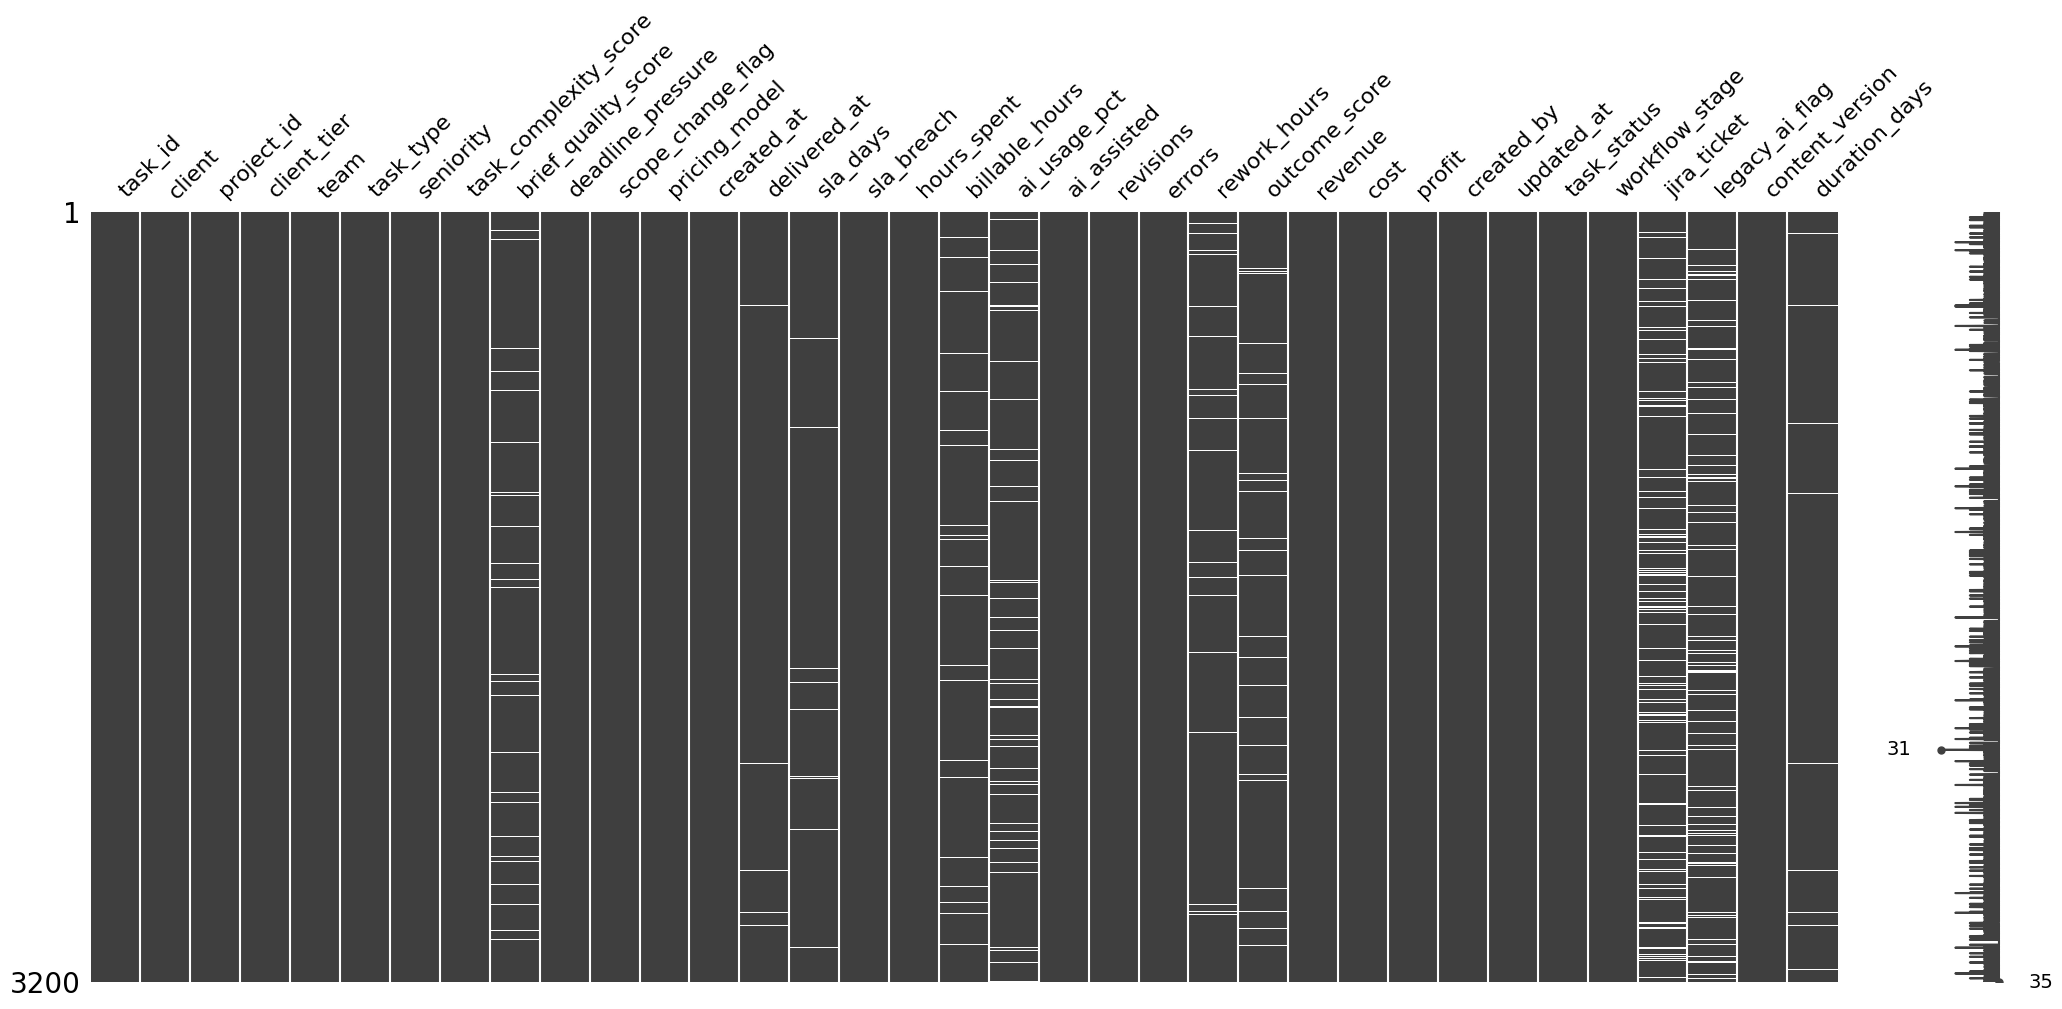

In [281]:
msno.matrix(df_productivity)

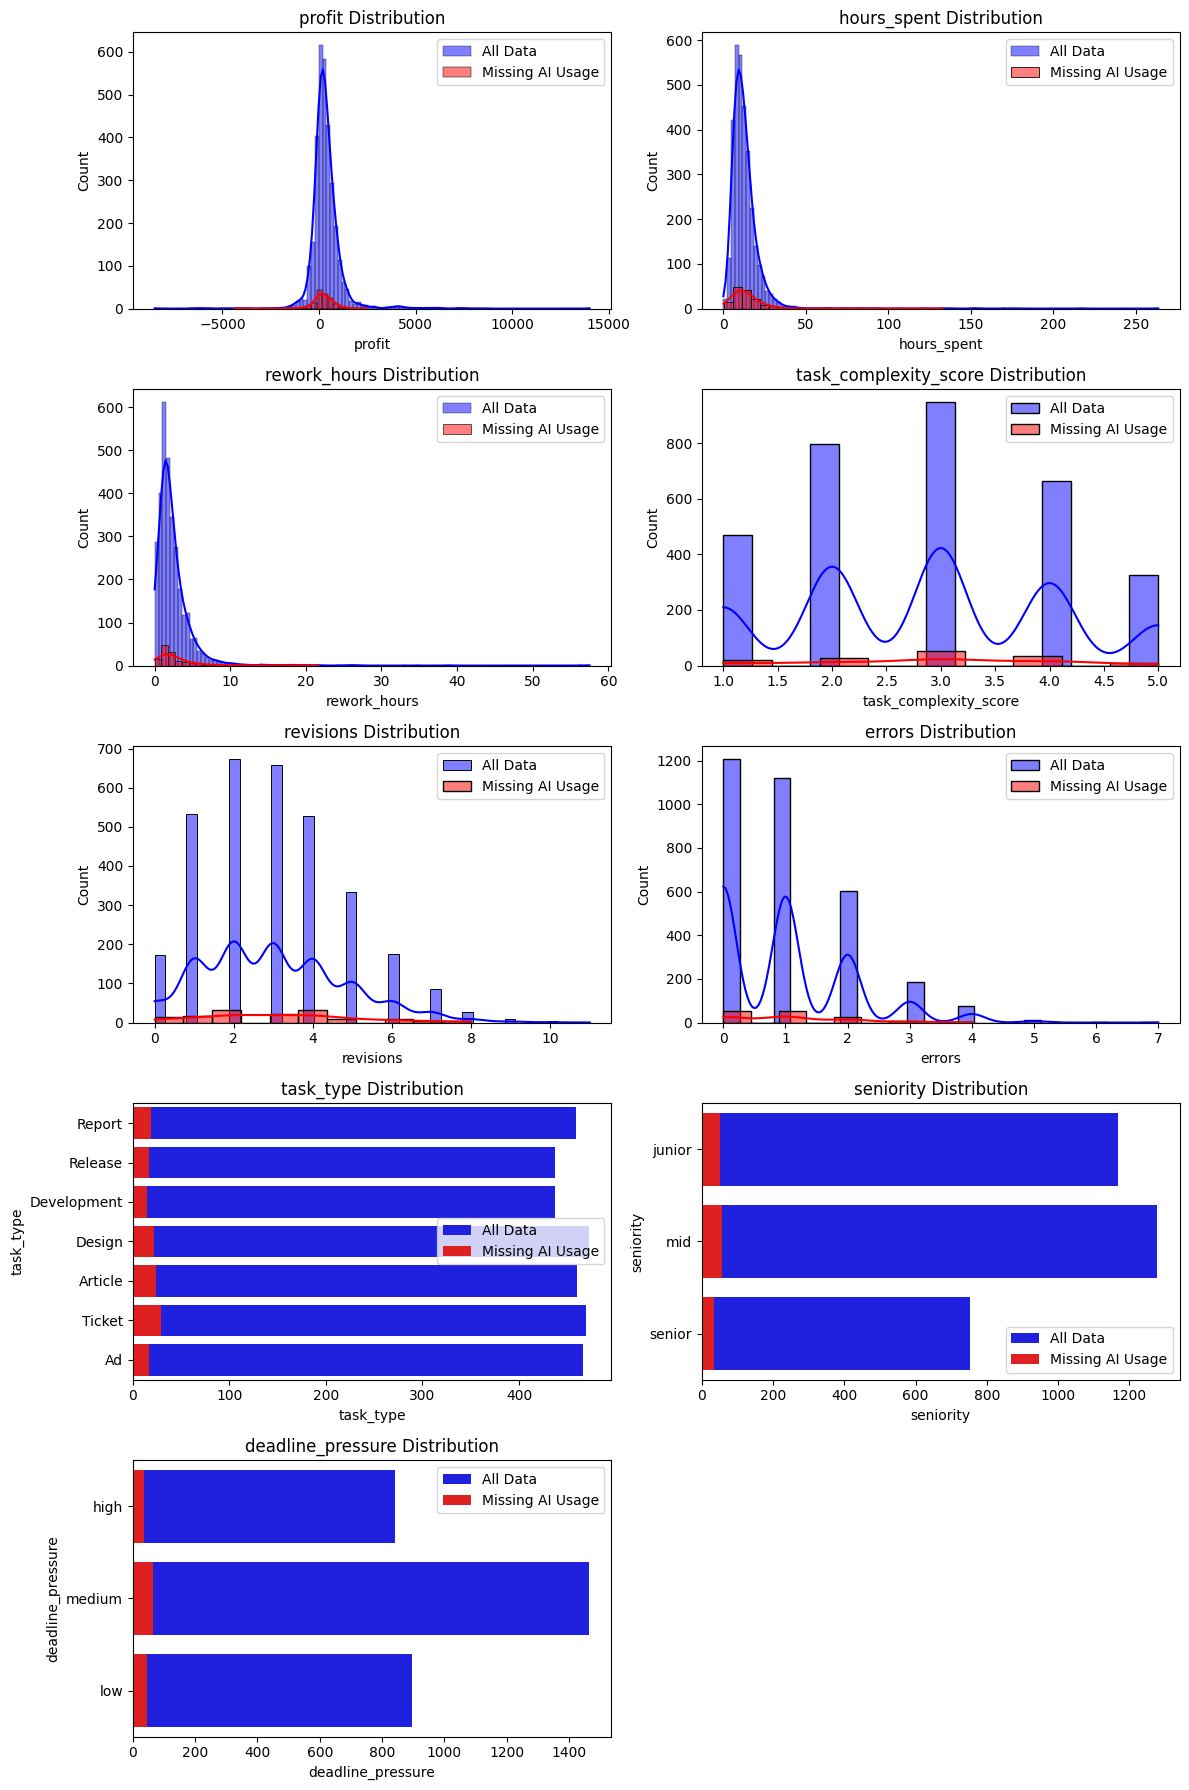

In [282]:
missing_ai_rows = df_productivity[df_productivity['ai_usage_pct'].isnull()]

columns = [
    'profit',
    'hours_spent',
    'rework_hours',
    'task_complexity_score',
    'revisions',
    'errors',
    'task_type',
    'seniority',
    'deadline_pressure'
]

fig, axes = plt.subplots(len(columns) // 2 + 1, 2, figsize=(12, 2 * len(columns)))
axes = axes.flatten()
for i, column in enumerate(columns):
    
    if column in df_productivity.select_dtypes(include=['int64', 'float64']).columns:
        sns.histplot(df_productivity[column], ax=axes[i], kde=True, color='blue', label='All Data')
        sns.histplot(missing_ai_rows[column], ax=axes[i], kde=True, color='red', label='Missing AI Usage')
    else:
        sns.countplot(data=df_productivity, y=column, ax=axes[i], color='blue', label='All Data')
        sns.countplot(data=missing_ai_rows, y=column, ax=axes[i], color='red', label='Missing AI Usage')
        
        axes[i].set_ylabel(column)
        axes[i].set_xlabel('Count')
    
    axes[i].set_title(f'{column} Distribution')
    axes[i].set_xlabel(column)
    axes[i].legend()

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()

#### Taking care of NaN values

In [283]:
df_productivity = df_productivity.drop(columns=['jira_ticket'], errors='ignore')

df_productivity['ai_usage_pct'] = df_productivity['ai_usage_pct'].fillna(
    df_productivity['ai_usage_pct'].median())

df_productivity['outcome_score'] = df_productivity['outcome_score'].fillna(
    df_productivity['outcome_score'].median())

df_productivity['brief_quality_score'] = df_productivity['brief_quality_score'].fillna(
    df_productivity['brief_quality_score'].median())

df_productivity['sla_days'] = df_productivity['sla_days'].fillna(
    df_productivity['sla_days'].median())

mask = df_productivity['billable_hours'].isna()
df_productivity.loc[mask, 'billable_hours'] = (
    df_productivity.loc[mask, 'hours_spent'] * 0.85)

df_productivity['rework_hours'] = df_productivity['rework_hours'].fillna(
    df_productivity['rework_hours'].median())

remaining = df_productivity.isnull().sum()
remaining = remaining[remaining > 0]

print("\nRemaining missing values:")
print(remaining)


Remaining missing values:
delivered_at       38
legacy_ai_flag    337
duration_days      52
dtype: int64


In [284]:
df_productivity['scope_change_flag'] = df_productivity['scope_change_flag'].astype(bool)
df_productivity['sla_breach']        = df_productivity['sla_breach'].astype(bool)

# Verify
print(df_productivity[['scope_change_flag', 'sla_breach']].dtypes)
display(df_productivity["scope_change_flag"].value_counts().to_frame())
display(df_productivity["sla_breach"].value_counts().to_frame())


scope_change_flag    bool
sla_breach           bool
dtype: object


,count
scope_change_flag,
False,2757
True,443


,count
sla_breach,
False,1929
True,1271


In [285]:
# Re-define num_cols
num_cols = [col for col in df_productivity.select_dtypes(include=['int64', 'float64']).columns if col != 'legacy_ai_flag']

# We have to exclude the column "legacy_ai_flag" now because after we standardized it, ir counts as a numeric column even if it shouldn't.

### Outlier Analysis Summary

After handling the missing values in the dataset, we turned our attention to identifying and treating extreme values in the numerical variables. The analysis was carried out in three stages.
#### 1. Visual Inspection via Boxplots
All 13 genuinely numerical columns were plotted as boxplots **before any transformation**, providing a first visual assessment of the distributional spread and the presence of extreme values.
#### Outlier Treatment — Decision not to cap
After visual inspection of the boxplots and IQR-based detection, we decided **not to apply winsorization** to any variable. The IQR × 3 rule flags statistically extreme values, but statistical extremity is not the same as an error. In this dataset:
- `hours_spent` reaches 263 hours: long tasks are real and analytically relevant. Capping them would systematically exclude the most complex tasks from the analysis, introducing selection bias.
- `revenue` reaches €14,927: large contracts are real business cases, not data entry errors. Removing them would bias the analysis toward average-sized tasks and underrepresent the high-margin segment.
- `rework_hours` reaches 57 hours: while high, this is plausible for tasks with severe quality issues, which are precisely the cases most relevant to our research question.
- `profit` ranges from €8,510 to +€14,006: the company confirmed that revenue and cost are estimated figures. This means the uncertainty is distributed across the entire dataset, not concentrated in the extremes. Capping the extremes while leaving the rest unchanged would be arbitrary.

For these reasons, we retain all observations as-is and rely on robust statistical methods downstream, specifically Spearman correlation (which is rank-based and less sensitive to extremes) and median-based imputation,rather than removing information from the dataset.

#### Check for outliers

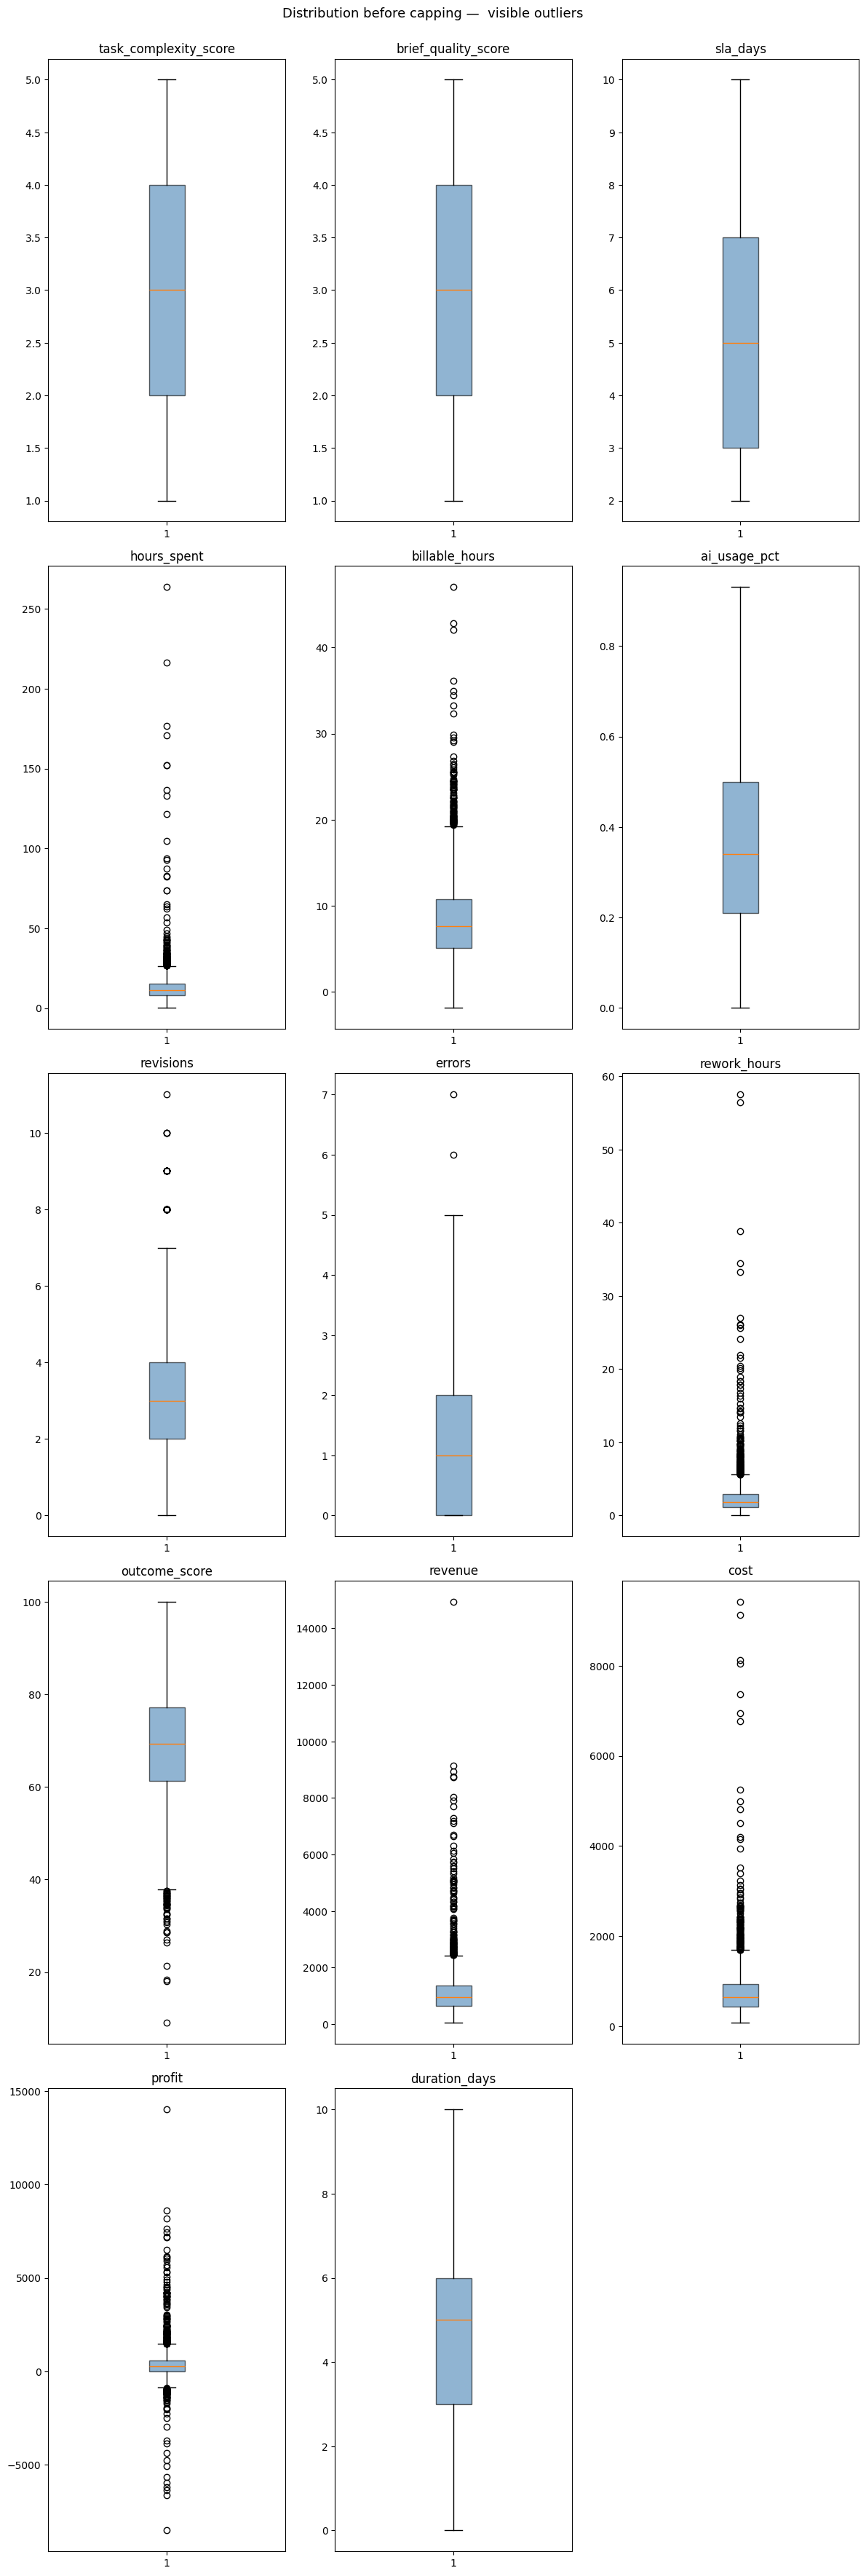

In [286]:
fig, axes = plt.subplots(len(num_cols) // 2 + 1, 3, figsize=(12, 4*len(num_cols)))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(df_productivity[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(f'{col}', fontsize=12)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
    
plt.suptitle('Distribution before capping —  visible outliers', fontsize=13, y = 1.0001)
plt.tight_layout()

In [287]:
outlier_summary = []

for col in num_cols:
    Q1 = df_productivity[col].quantile(0.25)
    Q3 = df_productivity[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Calculate 3x IQR bounds
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    
    n_out = ((df_productivity[col] < lower) | (df_productivity[col] > upper)).sum()
    pct = (n_out / len(df_productivity)) * 100
    
    # Append the results as a new row
    outlier_summary.append({
        'Feature': col,
        'Lower Bound': lower,
        'Upper Bound': upper,
        'Outlier Count': n_out,
        '% Outliers': pct
    })

# Convert to DataFrame
df_outliers = pd.DataFrame(outlier_summary)

# Display with clean formatting (rounds numbers and adds % sign)
display(df_outliers.style.hide(axis='index').format({
    'Lower Bound': '{:.2f}',
    'Upper Bound': '{:.2f}',
    '% Outliers': '{:.1f}%'
}).set_caption("Extreme Outliers (3 × IQR)"))

Feature,Lower Bound,Upper Bound,Outlier Count,% Outliers
task_complexity_score,-4.00,10.00,0,0.0%
brief_quality_score,-4.00,10.00,0,0.0%
sla_days,-9.00,19.00,0,0.0%
hours_spent,-14.37,37.59,38,1.2%
billable_hours,-11.91,27.78,12,0.4%
ai_usage_pct,-0.66,1.37,0,0.0%
revisions,-4.00,10.00,1,0.0%
errors,-6.00,8.00,0,0.0%
rework_hours,-4.28,8.32,71,2.2%
outcome_score,13.81,124.78,1,0.0%


### Outlier Treatment — Selective Capping

After inspecting the IQR-based detection table, we apply winsorization
selectively to the variables where extreme values are most likely to be
estimation errors rather than real business cases.

The company confirmed that `revenue` and `cost` are estimated figures,
which means `profit` (derived as revenue − cost) inherits that uncertainty.
A `profit` of −€8,510 or +€14,006 on a single task is almost certainly
a misestimate, not a real outcome. Capping these values limits their
disproportionate influence on regression coefficients and SHAP values
without removing the observations entirely.

We also cap `rework_hours` because values above the IQR × 3 upper bound
(8.32h) are implausible at the task level given the dataset's granularity —
a single task with 57 hours of rework is an extreme exception that would
distort any model trained on this data.

We deliberately do **not** cap `hours_spent` or `revenue` directly:
long tasks are real, and large contracts are real business cases.
The capping targets only the variables where the company's confirmation
of estimated data provides a methodological justification.

After capping, all derived features (`profit_margin`, `rework_rate`, etc.)
are computed from the cleaned values — ensuring internal consistency
between raw variables and the engineered metrics.

In [288]:
def cap_iqr(series, k=3):
    q1  = series.quantile(0.25)
    q3  = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    n_capped = ((series < lower) | (series > upper)).sum()
    return series.clip(lower, upper), int(n_capped)

# Only variables where estimation errors are plausible
cap_cols = ['profit', 'rework_hours']

print("=== Capping applied (IQR × 3) ===\n")

capping_log = []
for col in cap_cols:
    if col in df_productivity.columns:
        before_std = df_productivity[col].std()
        before_min = df_productivity[col].min()
        before_max = df_productivity[col].max()
        
        df_productivity[col], n = cap_iqr(df_productivity[col])
        
        after_std = df_productivity[col].std()
        after_min = df_productivity[col].min()
        after_max = df_productivity[col].max()
        
        capping_log.append({
            'Feature':      col,
            'Capped':       n,
            '% capped':     round(n / len(df_productivity) * 100, 2),
            'Std before':   round(before_std, 2),
            'Std after':    round(after_std, 2),
            'Range before': f'[{before_min:.1f}, {before_max:.1f}]',
            'Range after':  f'[{after_min:.1f}, {after_max:.1f}]',
        })

capping_df = pd.DataFrame(capping_log)
display(capping_df.style
        .hide(axis='index')
        .set_caption("Winsorization Summary — selective capping"))

print("\nAll other variables retained as-is.")
print("Feature engineering will be computed from these cleaned values.")

=== Capping applied (IQR × 3) ===



Feature,Capped,% capped,Std before,Std after,Range before,Range after
profit,79,2.470000,887.940000,591.020000,"[-8510.5, 14006.6]","[-1777.8, 2365.6]"
rework_hours,71,2.220000,2.890000,1.780000,"[0.0, 57.5]","[0.0, 8.3]"



All other variables retained as-is.
Feature engineering will be computed from these cleaned values.


Note: even after capping `profit` at IQR × 3 bounds, `profit_margin`
can still show extreme values when `revenue` is very small — the ratio
amplifies the capped profit into an implausible percentage. We therefore
apply a 1st–99th percentile clip to `profit_margin` directly after
computing it, retaining 98% of observations with no distortion.

### Correlation Analysis Summary

After handling missing values and deciding not to cap outliers, we explored the linear and monotonic relationships between the 13 genuinely numerical features using two complementary methods. `scope_change_flag` and `sla_breach` were excluded because they are binary flags — their dtype was already converted to `bool` in the cleaning phase, so they no longer appear in `select_dtypes(include=[np.number])`.

#### Why Two Methods?
- **Pearson** measures *linear* correlations: it assumes the relationship between two variables is a straight line.
- **Spearman** measures *monotonic* (rank-based) correlations: it captures non-linear relationships and is not influenced by outliers. It is the most robust method for this dataset, which contains extreme values that we chose not to cap.

Using both heatmaps together allows us to distinguish genuine associations from artifacts caused by skewed distributions.

---

#### Key Findings — Pearson

| Pair | Pearson r | Interpretation |
|--------|-----------|-----------------|
| `revenue` ↔ `profit` | **+0.77** | Strong: profit scales with revenue (expected) |
| `billable_hours` ↔ `cost` | **+0.55** | Billable hours drive total cost |
| `billable_hours` ↔ `hours_spent` | **+0.47** | Most worked hours are billable |
| `errors` ↔ `outcome_score` | **−0.47** | More errors → significantly lower perceived quality |
| `cost` ↔ `profit` | **−0.41** | For a given revenue, high costs squeeze the margin |
| `brief_quality_score` ↔ `outcome_score` | **+0.34** | Better briefs produce higher quality output |

Pairs involving `ai_usage_pct` show weak correlations with `profit` (r = +0.11), `rework_hours` (r = +0.12), and `outcome_score` (r = −0.02). This does not mean AI is irrelevant: it means its effect is **not linear** — an hypothesis that will be tested in the threshold analysis (Phase 5).

---

#### Key Findings — Spearman

| Pair | Spearman ρ | Interpretation |
|--------|------------|-----------------|
| `billable_hours` ↔ `hours_spent` | **+0.84** | Near-perfect relationship: confirms linearity |
| `cost` ↔ `hours_spent` | **+0.81** | Cost is primarily driven by hours worked |
| `billable_hours` ↔ `cost` | **+0.72** | Consistent with Pearson |
| `revenue` ↔ `profit` | **+0.66** | Stronger than Pearson → partially non-linear relationship |
| `errors` ↔ `outcome_score` | **−0.45** | Confirms Pearson finding — robust to outliers |
| `brief_quality_score` ↔ `rework_hours` | **−0.35** | **Relevant finding**: low-quality briefs → more rework hours |

Spearman is consistently higher than Pearson for pairs involving `hours_spent`, `cost`, and `revenue` — a sign that the skewed distributions of these values attenuated the linear correlation. The rank-based method captures them better.

---

#### Implications for the Research Question

The correlation between `ai_usage_pct` and the outcome variables (`profit`, `rework_hours`, `outcome_score`) is weak **at a linear and global level**. This result is expected and not contradictory: a threshold effect is by definition non-linear — it only appears when segmenting by usage tiers. The threshold analysis in the subsequent phases is therefore motivated by this very finding.

#### Correlation

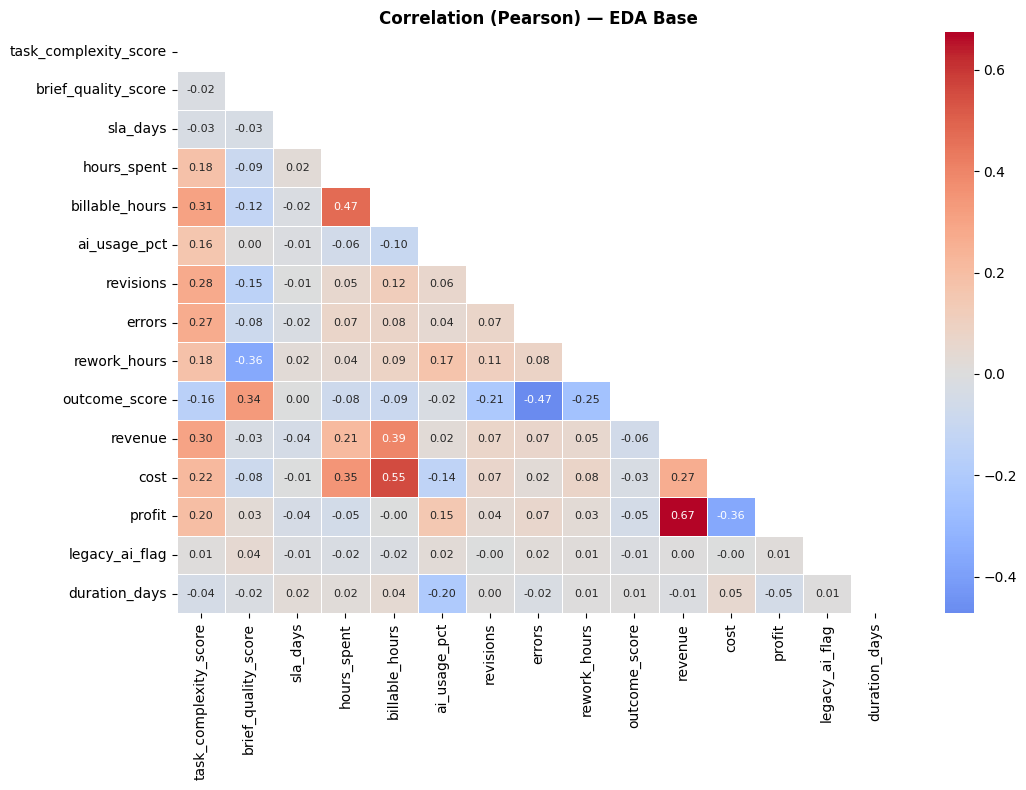

In [289]:
numeric = df_productivity.select_dtypes(include=[np.number])
exclude = ['scope_change_flag', 'sla_breach']
numeric = numeric.drop(columns=[c for c in exclude if c in numeric.columns])

corr = numeric.corr(method='pearson')
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(11, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.4,
            annot_kws={'size': 8})

plt.title('Correlation (Pearson) — EDA Base', fontweight='bold')
plt.tight_layout()

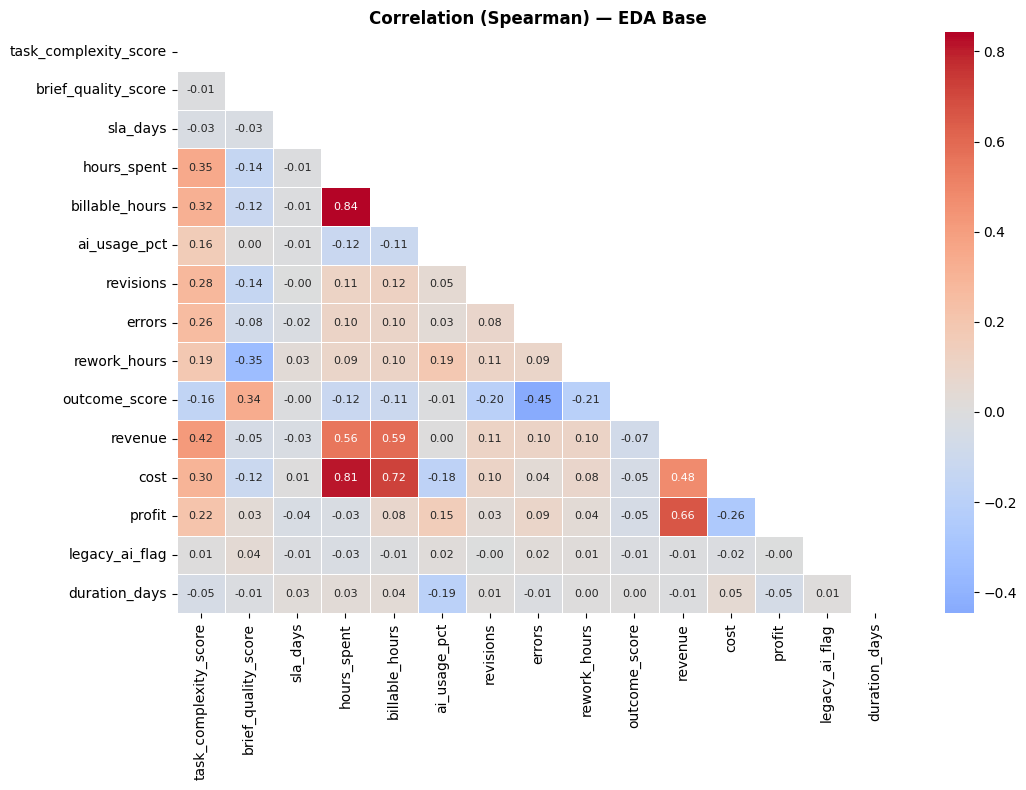

In [290]:
numeric = df_productivity.select_dtypes(include=[np.number])
exclude = ['scope_change_flag', 'sla_breach']
numeric = numeric.drop(columns=[c for c in exclude if c in numeric.columns])

corr = numeric.corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(11, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.4,
            annot_kws={'size': 8})

plt.title('Correlation (Spearman) — EDA Base', fontweight='bold')
plt.tight_layout()

## `Feature Engineering`

### Feature Engineering - Motivation and Created Variables

In this phase, we construct new variables from the already cleaned original data. The goal is to transform raw data into metrics that directly answer the research question: *beyond what threshold of AI usage does rework destroy the profit margin?*

The original variables (e.g., `profit`, `revenue`, `hours_spent`) are kept intact, they are neither capped nor modified, because they represent real business values. The new features are all **derived** variables calculated from the cleaned dataset.

The created features are:

| # | Variable | Formula | Motivation |
|---|-----------|---------|-------------|
| 1 | `profit_margin` | `profit / revenue × 100` | Normalized margin, comparable across tasks of different sizes |
| 2 | `ai_flag` | `ai_usage_pct > 0` → 0/1 | Distinguishes tasks with and without AI, for binary baseline comparisons |
| 3 | `rework_rate` | `rework_hours / hours_spent` | Proportion of wasted time (the primary hidden cost) |
| 4 | `error_rate` | `errors / hours_spent` | Error density per worked hour |
| 5 | `billable_ratio` | `billable_hours / hours_spent` | Share of work recovered as revenue |
| 6 | `revenue_per_hour` | `revenue / hours_spent` | Hourly revenue efficiency |
| 7 | `cost_per_hour` | `cost / hours_spent` | Hourly cost intensity |
| 8 | `ai_usage_sq` | `ai_usage_pct²` | Quadratic term to capture non-linear effects of AI on the margin |
| 9 | `rework_cost_est` | `rework_hours × median(cost_per_hour)` | Monetary estimate of the rework cost in € |
| 10 | `hidden_cost_ratio` | `rework_cost_est / cost` | Proportion of total cost attributable to rework |
| 11 | `ai_bucket` | bins of `ai_usage_pct` in five 20% intervals | Ordinal grouping for threshold analysis |
| 12 | `is_high_ai` | `ai_usage_pct >= 0.6` → 0/1 | Binary flag for tasks with high AI usage (threshold ≥ 60%) |
| 13 | `budget_bucket` | median of `revenue` → low/high | Segmentation by the economic size of the task |
| 14 | `profit_bucket` | median of `profit` → low/high | Segmentation by task profitability |
| 15 | `complexity_bucket` | tertiles of `task_complexity_score` | Segmentation by operational complexity level |

> **Technical note on ratios:** To avoid division by zero or extreme values caused by tasks with very few logged hours (e.g., 0.02h due to logging errors), the denominator `hours_spent` is clipped to a minimum of 0.1h before calculating all ratios. This does not alter the real values, it applies only to the 0.02% of cases with anomalous hours.

---

### Feature Engineering - Summary

The final dataframe now contains **34 original columns + 15 engineered features** for a total of 49 columns. The most relevant features for the threshold analysis in subsequent phases are:
* `profit_margin`: primary target variable
* `rework_rate` and `rework_cost_est`: mechanism of damage
* `ai_bucket` and `is_high_ai`: AI segmentation variables
* `hidden_cost_ratio`: hidden cost as a percentage of total cost

In [291]:
# -------------------------------------------------------------------
# NOTE: Negative billable_hours are set to NaN BEFORE using this column in ratios. Negative values are logging errors, not real values. 
# This operation happens here and not in the cleaning phase because the column was already imputed in the previous phase.
# -------------------------------------------------------------------
df_productivity.loc[
    df_productivity['billable_hours'] < 0, 'billable_hours'
] = np.nan

# 1 - Percentage profit margin
df_productivity['profit_margin'] = (
    df_productivity['profit'] / df_productivity['revenue'].replace(0, np.nan)
) * 100

# 2 - Binary flag: did the task use AI?
df_productivity['ai_flag'] = (df_productivity['ai_usage_pct'] > 0).astype(int)

# 3 - Hour-based ratios: using hours_safe to prevent division by near-zero values caused by logging errors (min = 0.1h)
min_hours = 0.1
hours_safe = df_productivity['hours_spent'].clip(lower=min_hours)

df_productivity['rework_rate'] = df_productivity['rework_hours'] / hours_safe
df_productivity['error_rate'] = df_productivity['errors'] / hours_safe
df_productivity['billable_ratio'] = df_productivity['billable_hours'] / hours_safe
df_productivity['revenue_per_hour'] = df_productivity['revenue'] / hours_safe
df_productivity['cost_per_hour'] = df_productivity['cost'] / hours_safe

# 4 - Quadratic term of ai_usage_pct (captures non-linear relationships)
df_productivity['ai_usage_sq'] = df_productivity['ai_usage_pct'] ** 2

# 5 - Monetary estimate of rework cost
# Using the median of cost_per_hour as a proxy for the company's hourly cost
median_cph = df_productivity['cost_per_hour'].median()
df_productivity['rework_cost_est'] = df_productivity['rework_hours'] * median_cph
df_productivity['hidden_cost_ratio'] = (
    df_productivity['rework_cost_est'] / df_productivity['cost'].replace(0, np.nan)
)
print(f"Median cost/hour used for rework_cost_est: €{median_cph:.2f}")

# 6 - AI segmentation into 5 buckets of 20% each
bins   = [0, 0.20, 0.40, 0.60, 0.80, 1.01]
labels = ['0-20%', '20-40%', '40-60%', '60-80%', '80-100%']
df_productivity['ai_bucket'] = pd.cut(
    df_productivity['ai_usage_pct'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# 7 - Binary flag: high AI usage (>= 60%)
df_productivity['is_high_ai'] = (df_productivity['ai_usage_pct'] >= 0.6).astype(int)

# 8 - Segmentation by economic size and complexity
df_productivity['budget_bucket'] = pd.qcut(
    df_productivity['revenue'], q=2,
    labels=['low_budget', 'high_budget']
)
df_productivity['profit_bucket'] = pd.qcut(
    df_productivity['profit'], q=2,
    labels=['low_profit', 'high_profit']
)
df_productivity['complexity_bucket'] = pd.qcut(
    df_productivity['task_complexity_score'], q=3,
    labels=['low', 'medium', 'high']
)

# 9 - Final check: print the newly created columns
new_features = [
    'profit_margin', 'ai_flag', 'rework_rate', 'error_rate',
    'billable_ratio', 'revenue_per_hour', 'cost_per_hour',
    'ai_usage_sq', 'rework_cost_est', 'hidden_cost_ratio',
    'ai_bucket', 'is_high_ai', 'budget_bucket', 'profit_bucket',
    'complexity_bucket'
]
print(f"\nFeatures created: {len(new_features)}")
print(f"Final dataframe shape: {df_productivity.shape}")
print("\nNon-null values for each new feature:")
display(df_productivity[new_features].notna().sum().to_frame(name='non-null count'))

Median cost/hour used for rework_cost_est: €58.07

Features created: 15
Final dataframe shape: (3200, 49)

Non-null values for each new feature:


,non-null count
profit_margin,3200
ai_flag,3200
rework_rate,3200
error_rate,3200
billable_ratio,3183
revenue_per_hour,3200
cost_per_hour,3200
ai_usage_sq,3200
rework_cost_est,3200
hidden_cost_ratio,3200


In [292]:
# profit_margin can still be extreme even after capping profit,
# because small revenue values amplify the ratio.
# We clip profit_margin to a plausible business range.

pm_lower, pm_upper = df_productivity['profit_margin'].quantile([0.01, 0.99])
n_clipped = ((df_productivity['profit_margin'] < pm_lower) |
             (df_productivity['profit_margin'] > pm_upper)).sum()

df_productivity['profit_margin'] = df_productivity['profit_margin'].clip(pm_lower, pm_upper)

print(f"profit_margin clipped at [{pm_lower:.1f}%, {pm_upper:.1f}%]")
print(f"Rows affected: {n_clipped} ({n_clipped/len(df_productivity)*100:.1f}%)")
print(f"New range: [{df_productivity['profit_margin'].min():.1f}, "
      f"{df_productivity['profit_margin'].max():.1f}]")

profit_margin clipped at [-239.0%, 81.4%]
Rows affected: 64 (2.0%)
New range: [-239.0, 81.4]


## `Advanced EDA`

### Analytical Strategy

The feature engineering phase produced all the variables needed to investigate the core research question: *beyond what threshold of AI usage does rework begin to erode profit margin performance?*

This section tests that question through a structured chain of analyses:

**AI -> Performance and Rework**
We first examine how `profit_margin` and `rework_rate` change across the five `ai_bucket` tiers (0-20%, 20-40%, 40-60%, 60-80%, 80-100%). A LOWESS smoother is then applied to the raw AI-profit relationship to reveal non-linear patterns without imposing a rigid functional form.

**Mechanism Checks**
We verify whether higher rework and hidden costs are associated with lower profitability through dedicated mechanism plots (`rework -> profit` and `hidden cost -> profit`).

**Segmentation**
We break the AI-margin relationship down by `budget_bucket` and `complexity_bucket` to test whether the pattern is uniform or concentrated in specific contexts.

**Threshold Readout in Two Steps**
We first report a clean levels table (median `profit_margin`, `rework_rate`, `hidden_cost_ratio`, and `hours_spent` by `ai_bucket`).
We then compute **marginal effects** (`profit_diff`, `rework_diff`, `hidden_diff`) to identify where gains peak and where cost pressure accelerates.

> All line plots use **median** as the estimator (rather than mean) because `profit_margin` is right-skewed, and the mean is sensitive to extreme values retained in the dataset.

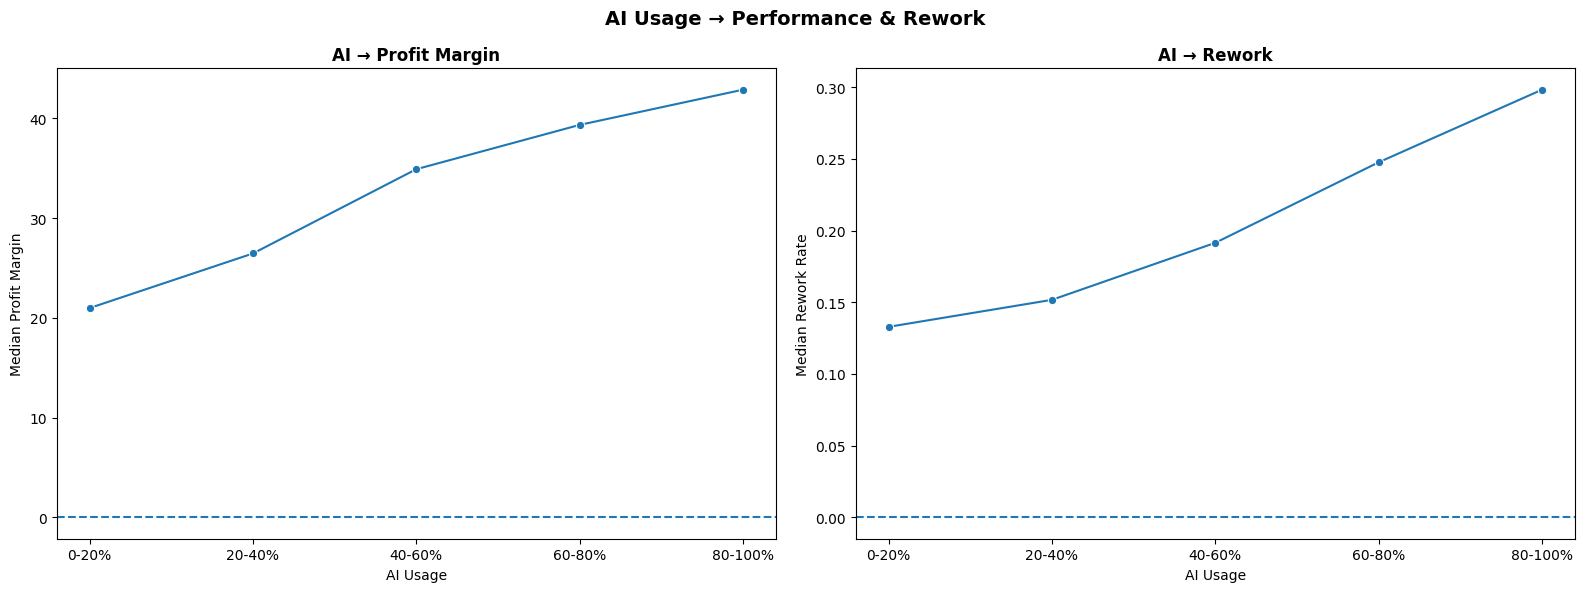

In [293]:

# ── 1. AI → Performance & Rework ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('AI Usage → Performance & Rework', fontsize=14, fontweight='bold')

sns.lineplot(data=df_productivity, x='ai_bucket', y='profit_margin',
             estimator='median', errorbar=None, marker='o', ax=axes[0])
axes[0].axhline(0, linestyle='--')
axes[0].set_title('AI → Profit Margin', fontweight='bold')
axes[0].set_xlabel('AI Usage')
axes[0].set_ylabel('Median Profit Margin')

sns.lineplot(data=df_productivity, x='ai_bucket', y='rework_rate',
             estimator='median', errorbar=None, marker='o', ax=axes[1])
axes[1].axhline(0, linestyle='--')
axes[1].set_title('AI → Rework', fontweight='bold')
axes[1].set_xlabel('AI Usage')
axes[1].set_ylabel('Median Rework Rate')

plt.tight_layout()

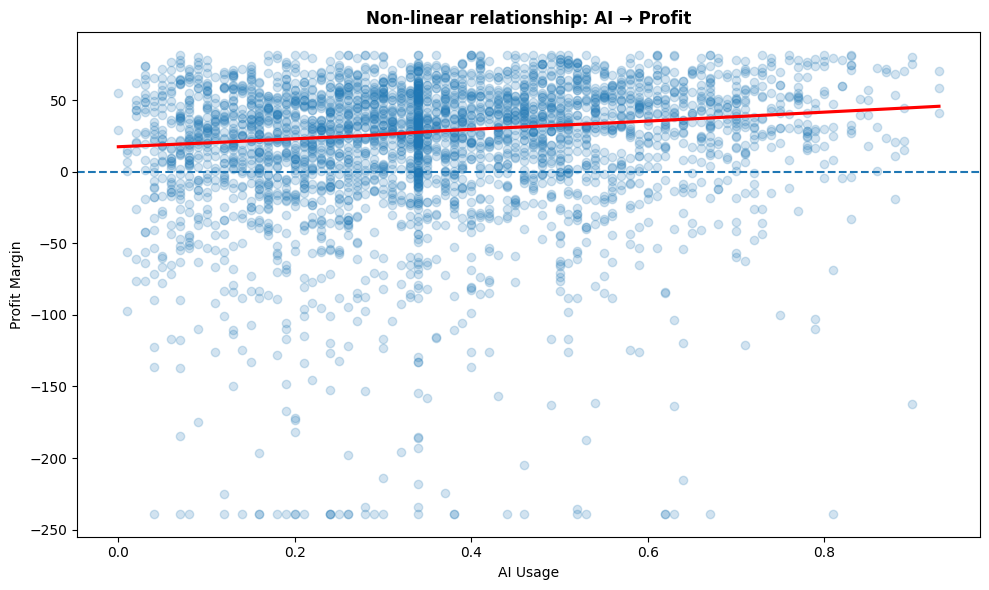

In [294]:
# ── 2. Non-linearity (LOWESS) ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(data=df_productivity, x='ai_usage_pct', y='profit_margin',
            lowess=True,
            scatter_kws={'alpha': 0.2},
            line_kws={'color': 'red'},
            ax=ax)
ax.axhline(0, linestyle='--')
ax.set_title('Non-linear relationship: AI → Profit', fontweight='bold')
ax.set_xlabel('AI Usage')
ax.set_ylabel('Profit Margin')
plt.tight_layout()

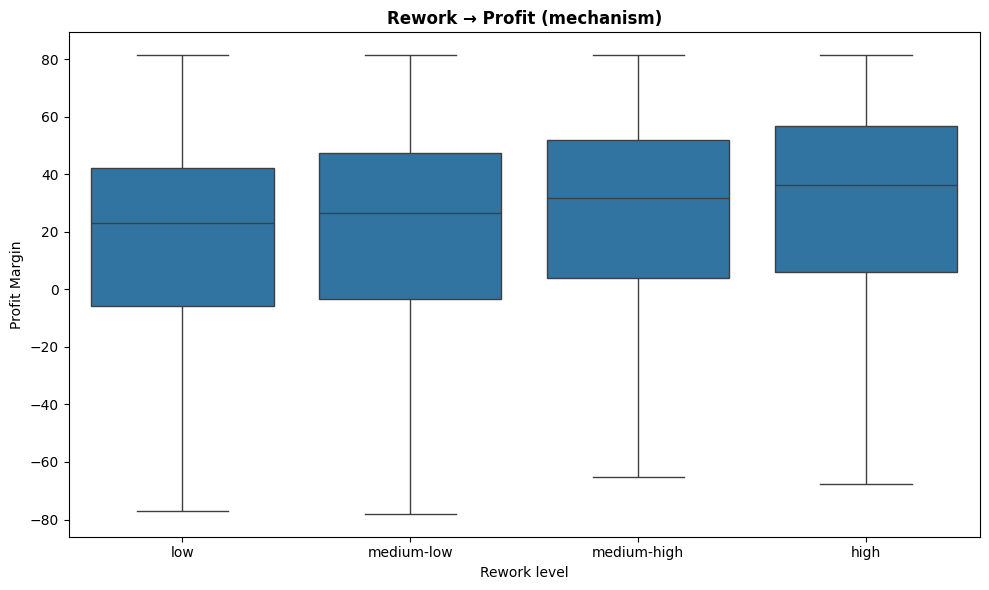

In [295]:
# ── 3. Rework → Profit (core mechanism) ──────────────────────
if 'rework_bin' not in df_productivity.columns:
    df_productivity['rework_bin'] = pd.qcut(
        df_productivity['rework_rate'], q=4,
        labels=['low', 'medium-low', 'medium-high', 'high']
    )

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_productivity, x='rework_bin', y='profit_margin',
            showfliers=False, ax=ax)
ax.set_title('Rework → Profit (mechanism)', fontweight='bold')
ax.set_xlabel('Rework level')
ax.set_ylabel('Profit Margin')
plt.tight_layout()

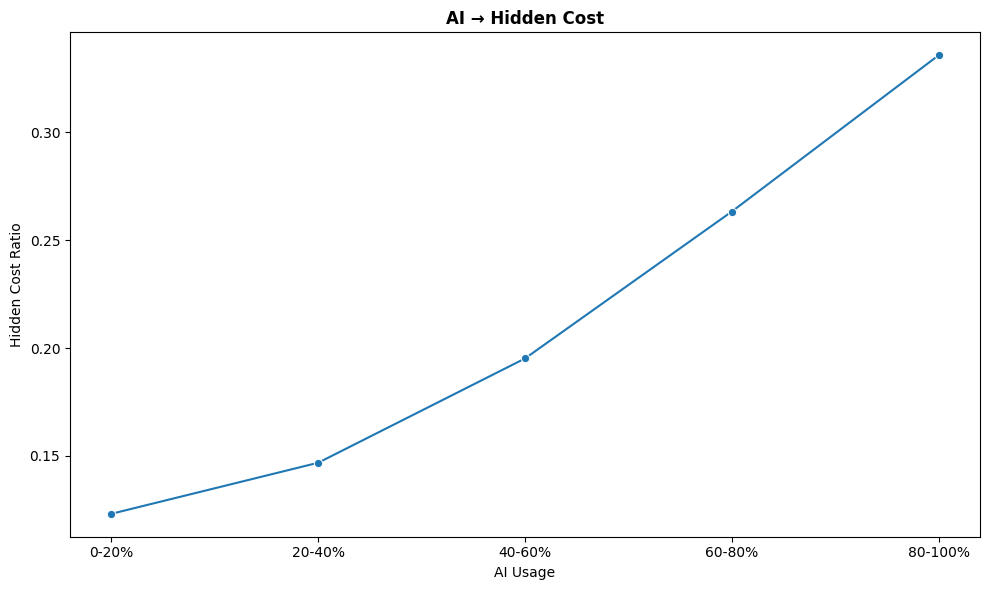

In [296]:
# ── 4. AI → Hidden cost (missing link) ───────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=df_productivity, x='ai_bucket', y='hidden_cost_ratio',
             estimator='median', errorbar=None, marker='o', ax=ax)
ax.set_title('AI → Hidden Cost', fontweight='bold')
ax.set_xlabel('AI Usage')
ax.set_ylabel('Hidden Cost Ratio')
plt.tight_layout()

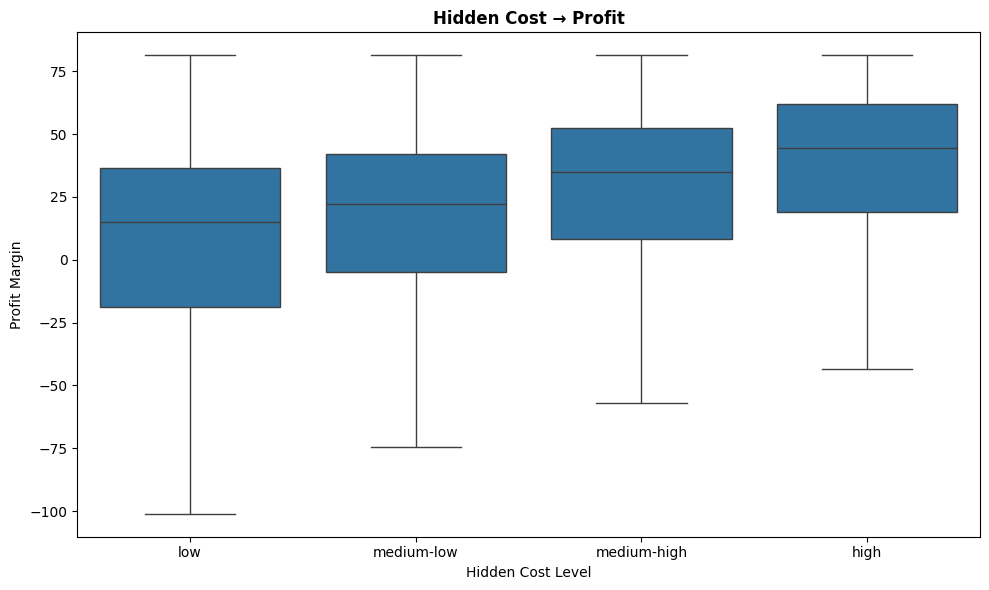

In [297]:
# ── 5. Hidden cost → Profit ───────────────────────────────────
if 'cost_bin' not in df_productivity.columns:
    df_productivity['cost_bin'] = pd.qcut(
        df_productivity['hidden_cost_ratio'], q=4,
        labels=['low', 'medium-low', 'medium-high', 'high']
    )

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_productivity, x='cost_bin', y='profit_margin',
            showfliers=False, ax=ax)
ax.set_title('Hidden Cost → Profit', fontweight='bold')
ax.set_xlabel('Hidden Cost Level')
ax.set_ylabel('Profit Margin')
plt.tight_layout()

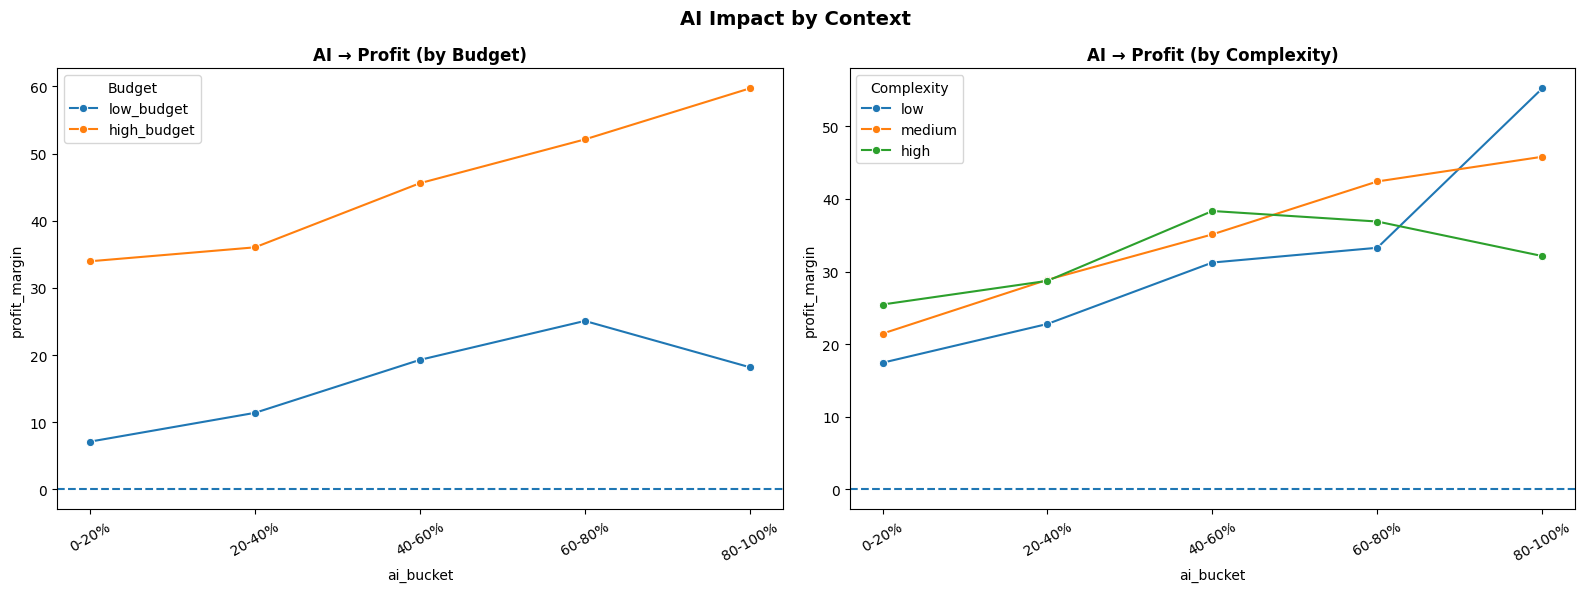

In [298]:
# ── 6. Segmentation: budget and complexity ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('AI Impact by Context', fontsize=14, fontweight='bold')

sns.lineplot(data=df_productivity, x='ai_bucket', y='profit_margin',
             hue='budget_bucket', estimator='median', errorbar=None,
             marker='o', ax=axes[0])
axes[0].axhline(0, linestyle='--')
axes[0].set_title('AI → Profit (by Budget)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

sns.lineplot(data=df_productivity, x='ai_bucket', y='profit_margin',
             hue='complexity_bucket', estimator='median', errorbar=None,
             marker='o', ax=axes[1])
axes[1].axhline(0, linestyle='--')
axes[1].set_title('AI → Profit (by Complexity)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[0].legend(title='Budget')
axes[1].legend(title='Complexity')

plt.tight_layout()

In [299]:
# ── 7. Threshold table (levels only) ───────────────────────────
threshold = df_productivity.groupby('ai_bucket', observed=True)[
    ['profit_margin', 'rework_rate', 'hidden_cost_ratio', 'hours_spent']
].median().round(3)
threshold = pd.DataFrame(threshold).reset_index()

print("=== Threshold Analysis (levels) ===")
display(threshold)

print("\nCounts per AI bucket:")
display(df_productivity['ai_bucket'].value_counts().sort_index().to_frame())

=== Threshold Analysis (levels) ===


,ai_bucket,profit_margin,rework_rate,hidden_cost_ratio,hours_spent
0,0-20%,20.981,0.133,0.123,11.615
1,20-40%,26.454,0.152,0.147,11.705
2,40-60%,34.902,0.191,0.195,10.700
3,60-80%,39.343,0.248,0.263,9.260
4,80-100%,42.873,0.298,0.336,10.240



Counts per AI bucket:


,count
ai_bucket,
0-20%,778
20-40%,1212
40-60%,812
60-80%,350
80-100%,48


# AI VS NO AI

### AI vs No-AI: Statistical Comparison

The threshold analysis segmented tasks by AI usage intensity. This section steps back and asks the binary question: do tasks that use *any* AI differ systematically from those that use none at all?

We compute mean differences across four outcomes (`profit_margin`, `rework_rate`, `hidden_cost_ratio`, and `hours_spent`) and test statistical significance using **Welch's two-sample t-test** (which does not assume equal variance between the two groups).

The t-test results are particularly informative here. Given the extreme variance in `profit_margin` caused by outlier tasks (some tasks have very large positive or negative margins), we expect the test to reveal whether the observed mean difference is distinguishable from noise. A non-significant result would confirm that the median (used in the threshold analysis) is the more reliable estimator for this dataset, as the mean is dominated by extreme values.

> Welch's t-test is used instead of Student's t-test because the two groups (AI / No AI) have different sizes and likely different variances.

In [300]:
# ── 1. Summary statistics ─────────────────────────────────────
baseline = df_productivity.groupby('ai_flag')[
    ['profit_margin', 'rework_rate', 'hidden_cost_ratio', 'hours_spent']
].mean().round(3)

baseline.index = ['No AI', 'AI used']

baseline = pd.DataFrame(baseline)
print("=== Mean values: AI vs No-AI ===")
display(baseline)


# ── 2. Difference (AI - No AI) ───────────────────────────────
diff = (baseline.loc['AI used'] - baseline.loc['No AI']).round(3)

display(diff.to_frame(name = "Difference (AI - No AI)"))

=== Mean values: AI vs No-AI ===


,profit_margin,rework_rate,hidden_cost_ratio,hours_spent
No AI,42.121,0.227,0.260,8.210
AI used,17.019,0.322,0.229,13.025


,Difference (AI - No AI)
profit_margin,-25.102
rework_rate,0.095
hidden_cost_ratio,-0.031
hours_spent,4.815


In [301]:
no_ai = df_productivity[df_productivity['ai_flag'] == 0]
ai = df_productivity[df_productivity['ai_flag'] == 1]

print("\n=== t-tests ===")

t_test = pd.DataFrame()
for var in ['profit_margin', 'rework_rate', 'hidden_cost_ratio', 'hours_spent']:
    t_stat, p_val = stats.ttest_ind(
        ai[var],
        no_ai[var],
        equal_var=False,
        nan_policy='omit'
    )
    
    sig = '***' if p_val < 0.001 else (
          '**'  if p_val < 0.01  else (
          '*'   if p_val < 0.05  else 'n.s.'))

    t_test[var] = ({
        't-statistic': t_stat,
        'p-value': p_val,
        'Significance': sig
    })


display(t_test.transpose())


=== t-tests ===


,t-statistic,p-value,Significance
profit_margin,-1.921895,0.303513,n.s.
rework_rate,0.511571,0.694293,n.s.
hidden_cost_ratio,-0.142017,0.910177,n.s.
hours_spent,2.58732,0.230058,n.s.


### Nonparametric Confirmation: Mann-Whitney U Test

The Welch's t-tests above operate on *means*. Since we established earlier that `profit_margin` is right-skewed and that the median is the more reliable central estimator for this dataset, consistency requires a complementary nonparametric test that does not assume normality.

The **Mann-Whitney U test** compares the full rank distributions of the two groups (AI vs No-AI) without assuming equal variances or normality. It is the nonparametric equivalent of the t-test and is appropriate when the median is the preferred estimator.


In [302]:
print("=== Mann-Whitney U tests (nonparametric) ===")
print("H₀: the two distributions are identical | α = 0.05")

u_test = pd.DataFrame()
for var in ['profit_margin', 'rework_rate', 'hidden_cost_ratio', 'hours_spent']:
    stat, p_val = mannwhitneyu(
        ai[var].dropna(),
        no_ai[var].dropna(),
        alternative='two-sided'
    )
    sig = '***' if p_val < 0.001 else (
          '**'  if p_val < 0.01  else (
          '*'   if p_val < 0.05  else 'n.s.'))
    
    u_test[var] = ({
        'U-statistic': stat,
        'p-value': p_val,
        'Significance': sig
    })

display(u_test.transpose())

=== Mann-Whitney U tests (nonparametric) ===
H₀: the two distributions are identical | α = 0.05


,U-statistic,p-value,Significance
profit_margin,2208.0,0.448722,n.s.
rework_rate,3278.0,0.951453,n.s.
hidden_cost_ratio,3195.0,0.998472,n.s.
hours_spent,4643.0,0.268775,n.s.


Both t-tests and Mann-Whitney tests are non-significant: the binary AI/No-AI split produces no statistically detectable difference by either method. This confirms that splitting by presence vs. absence of AI is not informative.
The signal lies in the intensity of adoption, as the threshold analysis shows.

### Reconciling the Apparent Contradiction

The two analyses above produce results that initially appear to tell opposite stories:

- **Binary split:** Tasks flagged as AI-used show a *lower* median profit margin (29.1%) than no-AI tasks (42.1%) → AI looks harmful  
- **Intensity split:** As AI usage increases bucket by bucket (0–20%, ..., 80–100%), the median margin rises monotonically from 21% to 49% → AI looks beneficial

These results are **fully compatible** once you look at what the "AI used" group actually contains:

- The binary flag `ai_flag = 1` captures **every** task with any AI involvement, from 0.1% to 93%. That includes the 0–20% intensity bucket (n=778), which has the **lowest median margin of all groups (20.98%)**, worse even than the heavy-AI tasks and almost as bad as tasks with no AI. These low-adoption tasks drag the entire "AI used" average down.

- The no-AI group (`ai_flag = 0`), on the other hand, is made up of tasks where teams consciously chose not to use AI, likely simpler, faster tasks (median 8.2h vs 11.1h), which naturally carry higher margins.

**The correct reading is therefore:**

> The binary comparison is misleading because it merges shallow AI adoption (0–20%) with deep AI adoption (60–100%). The real variable that matters is not *whether* AI was used, but *how intensively*. Partial, low-confidence AI usage is associated with the worst outcomes in the dataset. Deep adoption is associated with the best.

This reframes the research question: the relevant threshold is not **whether** AI is used, but **at what depth of adoption** its effect turns positive.



# Trade-off Analysis


### Speed, Quality, and Value: Decomposing the AI Effect

The threshold table showed that `profit_margin` rises monotonically with AI usage intensity. But a higher margin could stem from two very different mechanisms:

1. **Speed**: AI reduces `hours_spent`, lowering cost and expanding margin.
2. **Quality**: AI reduces errors and rework, improving output quality and client retention.

We examine three separate outcome variables across `ai_bucket` tiers:
- `hours_spent`: proxy for speed (lower = faster)
- `rework_hours`: proxy for quality (lower = fewer corrections needed)
- `profit`: absolute value created

A scatter of `hours_spent` vs `profit` coloured by AI usage tier then shows whether the two dimensions move together or trade off against each other.

> All estimators use **median** to guard against the influence of extreme values.

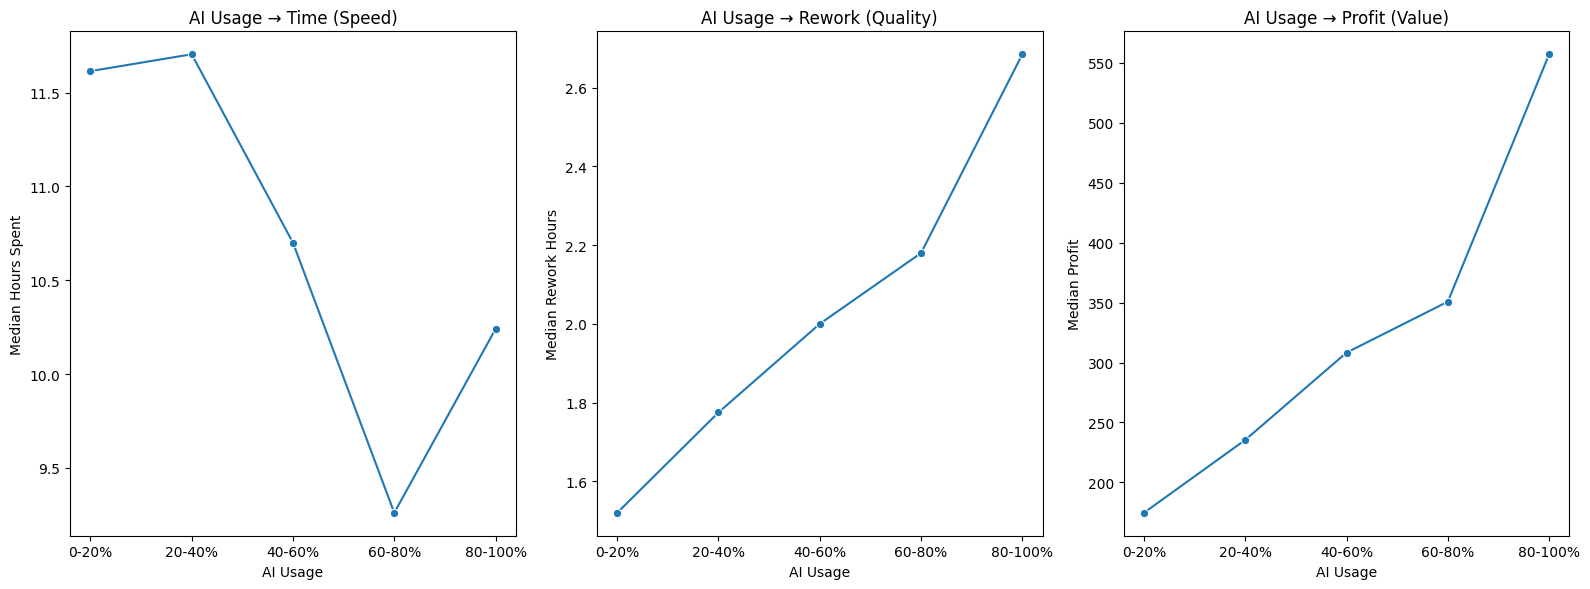

In [303]:
# ── 1. AI → SPEED
fig, ax = plt.subplots(1,3,figsize=(16, 6))

sns.lineplot(
    data=df_productivity,
    x='ai_bucket',
    y='hours_spent',
    estimator='median',
    errorbar=None,
    marker='o',
    ax=ax[0]
)

ax[0].set_title('AI Usage → Time (Speed)')
ax[0].set_xlabel('AI Usage')
ax[0].set_ylabel('Median Hours Spent')
plt.tight_layout()


# ── 2. AI → QUALITY (rework)

sns.lineplot(
    data=df_productivity,
    x='ai_bucket',
    y='rework_hours',
    estimator='median',
    errorbar=None,
    marker='o',
    ax=ax[1]
)

ax[1].set_title('AI Usage → Rework (Quality)')
ax[1].set_xlabel('AI Usage')
ax[1].set_ylabel('Median Rework Hours')
plt.tight_layout()


# ── 3. AI → VALUE (profit)

sns.lineplot(
    data=df_productivity,
    x='ai_bucket',
    y='profit',
    estimator='median',
    errorbar=None,
    marker='o',
    ax=ax[2]
)

ax[2].set_title('AI Usage → Profit (Value)')
ax[2].set_xlabel('AI Usage')
ax[2].set_ylabel('Median Profit')
plt.tight_layout()

### Speed vs. Value: Are Fast Tasks Also Profitable?

The line plot above (AI → Time) showed that hours spent **decrease** as AI usage deepens within the adoption spectrum, from 11.6h at 0–20% down to 9.3h at 60–80%. This means that among tasks where AI is used, higher AI intensity is associated with faster execution.

However, AI-using tasks overall are still slower than no-AI tasks (11.1h vs 8.2h in the binary comparison) suggesting that AI is selectively applied to larger, more complex tasks that inherently take longer, and that deeper AI usage then recovers some of that time.

This scatter plot maps each task by `hours_spent` (x-axis) vs `profit` (y-axis), coloured by AI usage bucket. It asks two questions simultaneously:

1. Is there a speed-value trade-off? (Do slower tasks produce more profit, or less?)
2. Do high-AI tasks occupy a distinct region of the speed-profit space, suggesting AI reshapes the relationship between effort and value?


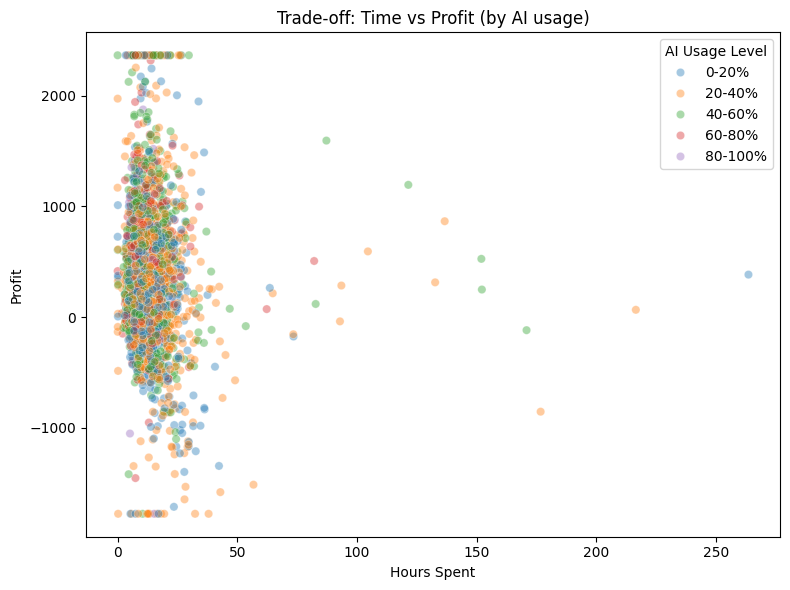

In [304]:
# SPEED vs VALUE

fig, ax = plt.subplots(figsize=(8, 6))

sns.scatterplot(
    data=df_productivity,
    x='hours_spent',
    y='profit',
    hue='ai_bucket',
    alpha=0.4,
    ax=ax
)

ax.set_title('Trade-off: Time vs Profit (by AI usage)')
ax.set_xlabel('Hours Spent')
ax.set_ylabel('Profit')
ax.legend(title='AI Usage Level')

plt.tight_layout()

# Threshold Detection

### Marginal Effects and the Point of Diminishing Returns

The previous analyses show that `profit_margin` generally increases with AI usage intensity. To make this result operational, we focus on **marginal effects**: the step-by-step change in outcomes when moving from one AI bucket to the next.

This section is organized as follows:

1. A threshold **levels table** summarizes median values by bucket (`profit_median`, `rework_median`, `hidden_median`, `time_median`).
2. First differences are computed (`profit_diff`, `rework_diff`, `hidden_diff`) to quantify incremental gains and costs.
3. A marginal-effects visualization highlights where profit gains are strongest and where rework/hidden costs accelerate.

The tier with the highest `profit_diff` is interpreted as the empirical peak in marginal benefit. If cost-side deltas continue rising after that point, the result indicates a practical diminishing-returns zone rather than a sharp negative threshold.

> The 80-100% bucket contains only 48 tasks, so estimates in that tier should be interpreted with caution.

=== Threshold table with marginal effects ===


,ai_bucket,profit_median,profit_std,n_obs,rework_median,hidden_median,time_median,profit_diff,rework_diff,hidden_diff
0,0-20%,20.981,55.475,778,0.133,0.123,11.615,0.000,0.000,0.000
1,20-40%,26.454,53.288,1212,0.152,0.147,11.705,5.473,0.019,0.024
2,40-60%,34.902,45.968,812,0.191,0.195,10.700,8.448,0.039,0.048
3,60-80%,39.343,49.461,350,0.248,0.263,9.260,4.441,0.057,0.068
4,80-100%,42.873,59.321,48,0.298,0.336,10.240,3.530,0.050,0.073


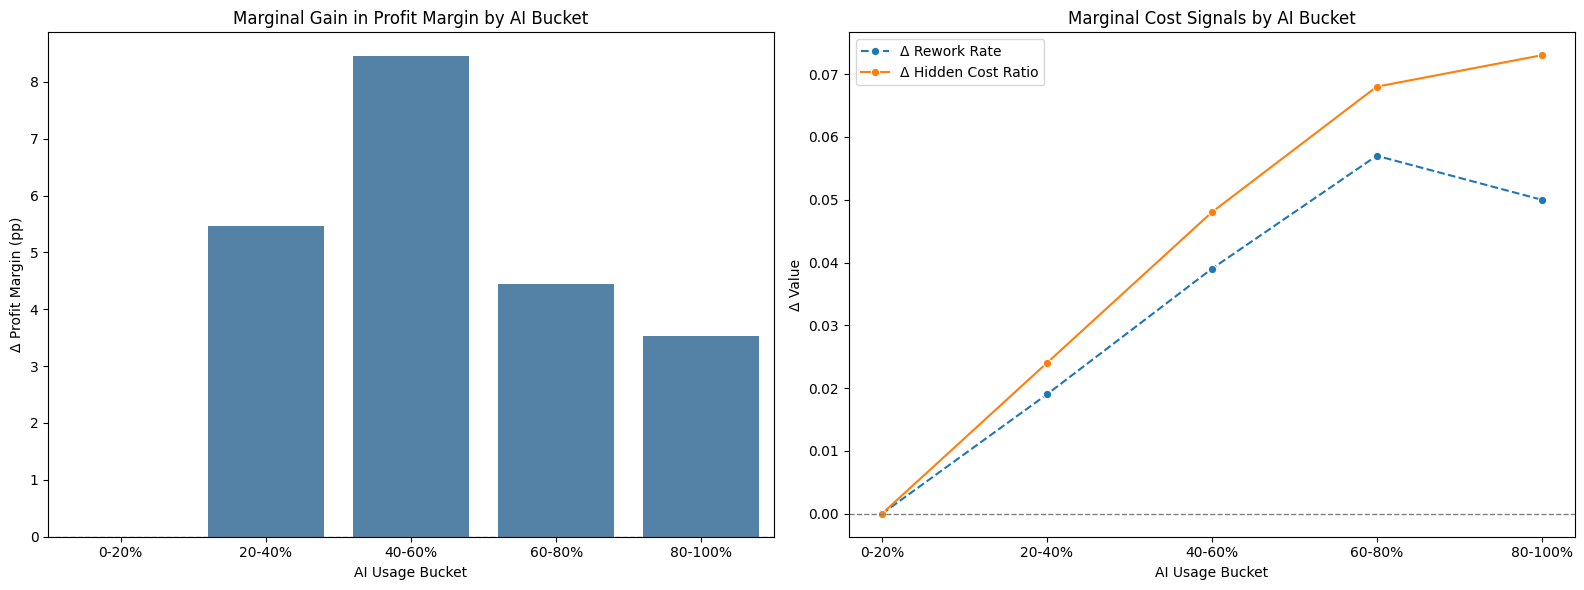

In [305]:
# THRESHOLD DETECTION (marginal effects, no duplicated level plots)

threshold_df = df_productivity.groupby('ai_bucket', observed=True).agg(
    profit_median=('profit_margin', 'median'),
    profit_std=('profit_margin', 'std'),
    n_obs=('profit_margin', 'count'),
    rework_median=('rework_rate', 'median'),
    hidden_median=('hidden_cost_ratio', 'median'),
    time_median=('hours_spent', 'median')
).round(3).reset_index()

threshold_df['profit_diff'] = threshold_df['profit_median'].diff().fillna(0)
threshold_df['rework_diff'] = threshold_df['rework_median'].diff().fillna(0)
threshold_df['hidden_diff'] = threshold_df['hidden_median'].diff().fillna(0)

print("=== Threshold table with marginal effects ===")
display(threshold_df)

# ── Marginal effects plot (new information vs previous cells) ──
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=threshold_df,
    x='ai_bucket',
    y='profit_diff',
    color='steelblue',
    ax=ax[0]
)
ax[0].axhline(0, linestyle='--', linewidth=1, color='gray')
ax[0].set_title('Marginal Gain in Profit Margin by AI Bucket')
ax[0].set_xlabel('AI Usage Bucket')
ax[0].set_ylabel('Δ Profit Margin (pp)')

sns.lineplot(
    data=threshold_df,
    x='ai_bucket',
    y='rework_diff',
    marker='o',
    linestyle='--',
    label='Δ Rework Rate',
    ax=ax[1]
)
sns.lineplot(
    data=threshold_df,
    x='ai_bucket',
    y='hidden_diff',
    marker='o',
    label='Δ Hidden Cost Ratio',
    ax=ax[1]
)
ax[1].axhline(0, linestyle='--', linewidth=1, color='gray')
ax[1].set_title('Marginal Cost Signals by AI Bucket')
ax[1].set_xlabel('AI Usage Bucket')
ax[1].set_ylabel('Δ Value')
ax[1].legend(loc='upper left')

plt.tight_layout()

In [306]:
# Ensure buckets are processed in their categorical order before reading the marginal gain
threshold_df = threshold_df.sort_values('ai_bucket').reset_index(drop=True)

best_idx = threshold_df['profit_diff'].idxmax()
best_bucket = threshold_df.loc[best_idx, 'ai_bucket']
best_value = threshold_df.loc[best_idx, 'profit_diff']

print("\n=== Empirical threshold ===")
print(f"Highest marginal gain: {best_bucket} (Δ = {best_value:.2f})")


=== Empirical threshold ===
Highest marginal gain: 40-60% (Δ = 8.45)


# Loss Analysis 


### Loss Analysis: Rework as the Margin Compression Mechanism

Even if AI does not cause a net margin inversion at the aggregate level, individual tasks can still lose money because of rework. This section isolates the rework-profit mechanism directly, bypassing AI usage as an intermediate variable.

The key question is: does `rework_cost_est` compress `profit_margin` on its own, regardless of what caused the rework? We test this with:

1. **Pearson and Spearman correlations** between `rework_cost_est` and `profit_margin` to detect both linear and monotonic relationships.
2. **A LOWESS smoother** on the scatter to visualize any non-linearity in the relationship.
3. **Quartile segmentation**: tasks are divided into four rework cost levels, and their median `profit_margin` is compared.
4. **The full mechanism table**: `rework_rate` → `rework_cost_est` → `profit_margin` by `ai_bucket`, to confirm whether rework is the channel through which AI usage affects profitability.

If rework cost compresses margins, any intervention that increases rework, AI-related or not, will erode value. This makes rework management the primary lever for improving profitability under any AI adoption strategy.

=== Pearson correlation: Rework Cost vs Profit Margin ===


,rework_cost_est,profit_margin
rework_cost_est,1.00,0.01
profit_margin,0.01,1.00



=== Spearman correlation: Rework Cost vs Profit Margin ===


,rework_cost_est,profit_margin
rework_cost_est,1.000,0.023
profit_margin,0.023,1.000


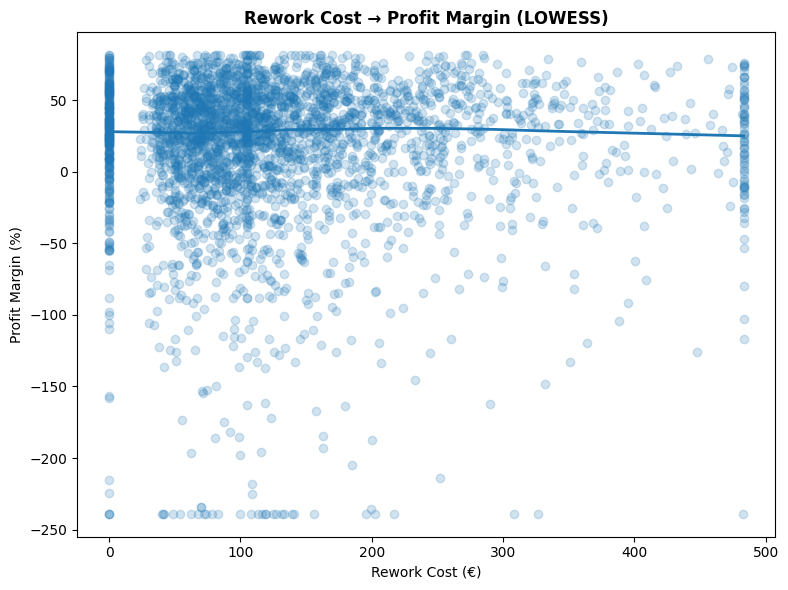

In [307]:
#  Correlation: rework cost vs profit 
corr_pearson = df_productivity[['rework_cost_est', 'profit_margin']].corr().round(3)

print("=== Pearson correlation: Rework Cost vs Profit Margin ===")
display(corr_pearson)

corr_spearman = df_productivity[['rework_cost_est', 'profit_margin']].corr(method='spearman').round(3)

print("\n=== Spearman correlation: Rework Cost vs Profit Margin ===")
display(corr_spearman)



fig, ax = plt.subplots(figsize=(8, 6))

sns.regplot(
    data=df_productivity,
    x='rework_cost_est',
    y='profit_margin',
    lowess=True,
    scatter_kws={'alpha': 0.2},
    line_kws={'linewidth': 2},
    ax=ax
)

ax.set_title('Rework Cost → Profit Margin (LOWESS)', fontweight='bold')
ax.set_xlabel('Rework Cost (€)')
ax.set_ylabel('Profit Margin (%)')

plt.tight_layout()


In [308]:
if 'rework_cost_bin' not in df_productivity.columns:
    df_productivity['rework_cost_bin'] = pd.qcut(
        df_productivity['rework_cost_est'],
        q=4,
        labels=['low', 'medium-low', 'medium-high', 'high']
    )

loss_analysis = df_productivity.groupby(
    'rework_cost_bin', observed=True
)['profit_margin'].median().round(2)

print("\n=== Median Profit Margin by Rework Cost Level ===")
display(loss_analysis.to_frame())


=== Median Profit Margin by Rework Cost Level ===


,profit_margin
rework_cost_bin,
low,27.52
medium-low,28.62
medium-high,29.61
high,31.57



=== Mechanism: AI → Rework → Cost → Profit ===


,rework_rate,rework_cost_est,profit_margin
ai_bucket,,,
0-20%,0.13,88.27,20.98
20-40%,0.15,103.08,26.45
40-60%,0.19,116.14,34.90
60-80%,0.25,126.59,39.34
80-100%,0.30,155.92,42.87


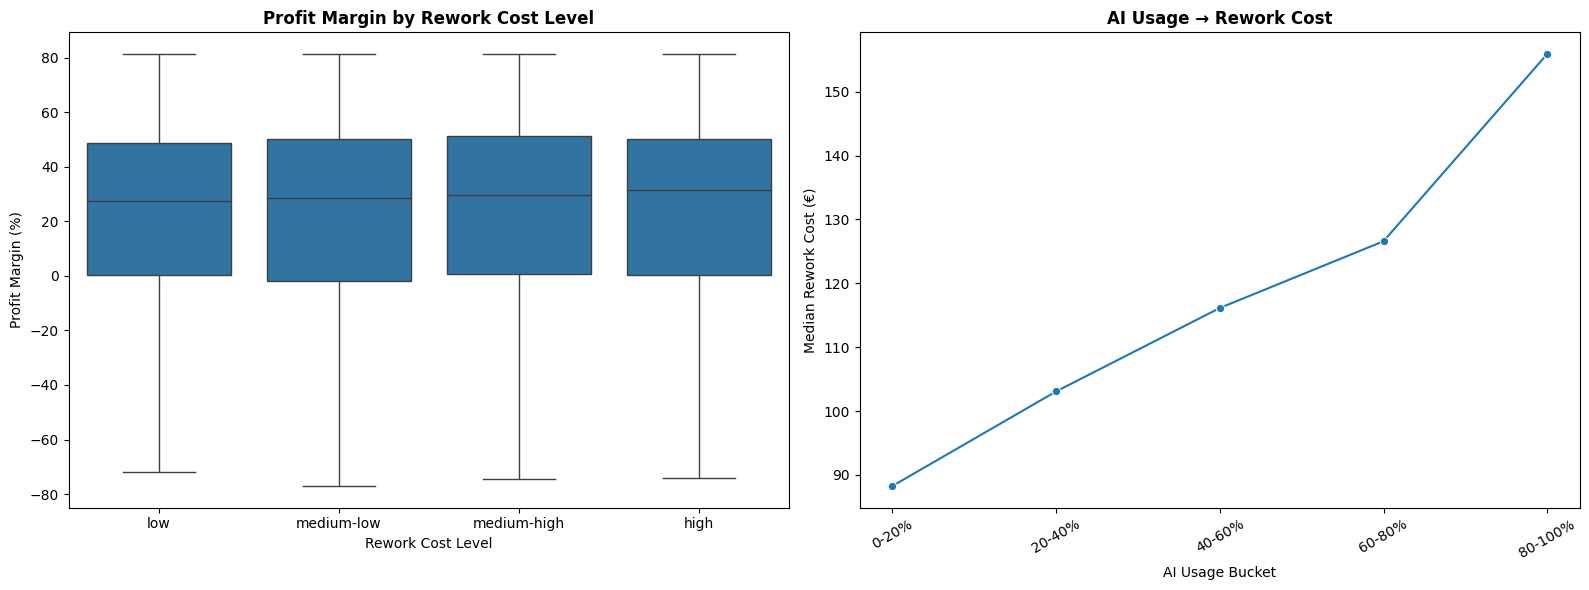

In [309]:
fig, ax = plt.subplots(1,2,figsize=(16, 6))

sns.boxplot(
    data=df_productivity,
    x='rework_cost_bin',
    y='profit_margin',
    showfliers=False,
    ax=ax[0]
)

ax[0].set_title('Profit Margin by Rework Cost Level', fontweight='bold')
ax[0].set_xlabel('Rework Cost Level')
ax[0].set_ylabel('Profit Margin (%)')

plt.tight_layout()

# ── AI → Rework Cost ─────────────────────────────────────────
sns.lineplot(
    data=df_productivity,
    x='ai_bucket',
    y='rework_cost_est',
    estimator='median',
    errorbar=None,
    marker='o',
    ax=ax[1]
)

ax[1].set_title('AI Usage → Rework Cost', fontweight='bold')
ax[1].set_xlabel('AI Usage Bucket')
ax[1].set_ylabel('Median Rework Cost (€)')
ax[1].tick_params(axis='x', rotation=30)

plt.tight_layout()

mechanism = df_productivity.groupby('ai_bucket', observed=True)[
    ['rework_rate', 'rework_cost_est', 'profit_margin']
].median().round(2)

print("\n=== Mechanism: AI → Rework → Cost → Profit ===")
display(mechanism)

### The Rework Paradox: Why Higher Rework Does Not Destroy Margins

The analysis above produces a counter-intuitive result that contradicts the original hypothesis.

**What we expected:** higher `rework_cost_est` → lower `profit_margin` (rework eats into profit)  
**What the data shows:** median profit margin *increases* with rework level, from 27.6% (low rework) to 31.6% (high rework). The mechanism table confirms the same pattern: the 80100% AI bucket has the highest rework rate (0.30) *and* the highest profit margin (49%).

**The probable mechanism: the complexity premium**

Tasks that use AI intensively tend to be larger, more complex, and higher-revenue. The same characteristics that make a task complex (ambiguous brief, multiple stakeholders, iterative deliverables) also generate more rework. But these same tasks command significantly higher revenue, and the revenue premium outpaces the rework cost.

In other words: rework is a *symptom of complexity*, not an independent cost driver. For a given task, more rework does compress the margin. But across the dataset, high-rework tasks also happen to be high-revenue tasks. The correlation between rework and margin is positive because both co-vary with a third variable: task size and complexity.

**The implication for the research question:**

Rework is *not* the mechanism through which AI destroys margins because in this dataset, AI does not destroy margins at all at the aggregate level. The real trade-off is subtler: AI raises both revenue (by enabling more ambitious deliverables) and rework (by increasing the complexity of what gets attempted). Whether a specific task benefits depends on whether the revenue premium exceeds the rework cost, which the segmented analysis in the next section will investigate by team and task type.

## `Segmented Analysis`

### Where Does AI Actually Help? Breaking Down the Effect by Team and Task Type

The aggregate threshold analysis confirmed that higher AI usage is associated with higher median margins across the full dataset. But this average obscures potential structural differences: AI may be systematically beneficial for some teams and neutral (or harmful) for others, and the type of work may matter as much as the team.

This section disaggregates the AI-margin relationship along two dimensions:

1. **Team** (Content, Media, Design, SEO): each team operates on different deliverables, different revision cycles, and different baseline familiarity with AI tools.
2. **Task type**: different categories of work may respond differently to AI assistance: structured or repetitive tasks may benefit more than creative or judgment-intensive ones.

For each dimension we compute the **median `profit_margin`** per `ai_bucket` and display it as a heatmap. A row that rises from left (low AI) to right (high AI) indicates a segment where deeper AI adoption consistently pays off. A flat or declining row indicates a segment where AI provides little marginal benefit.

A companion count heatmap is shown alongside each margin heatmap to flag cells with fewer than ~20 tasks, where the median estimate is less reliable.



=== Median Profit Margin by Team × AI Bucket ===


ai_bucket,0-20%,20-40%,40-60%,60-80%,80-100%
team,,,,,
Content,18.7,28.8,35.9,40.7,41.9
Design,18.6,23.9,29.3,38.8,49.2
Media,21.4,30.1,38.5,38.0,45.8
SEO,22.2,21.6,35.0,41.5,25.0


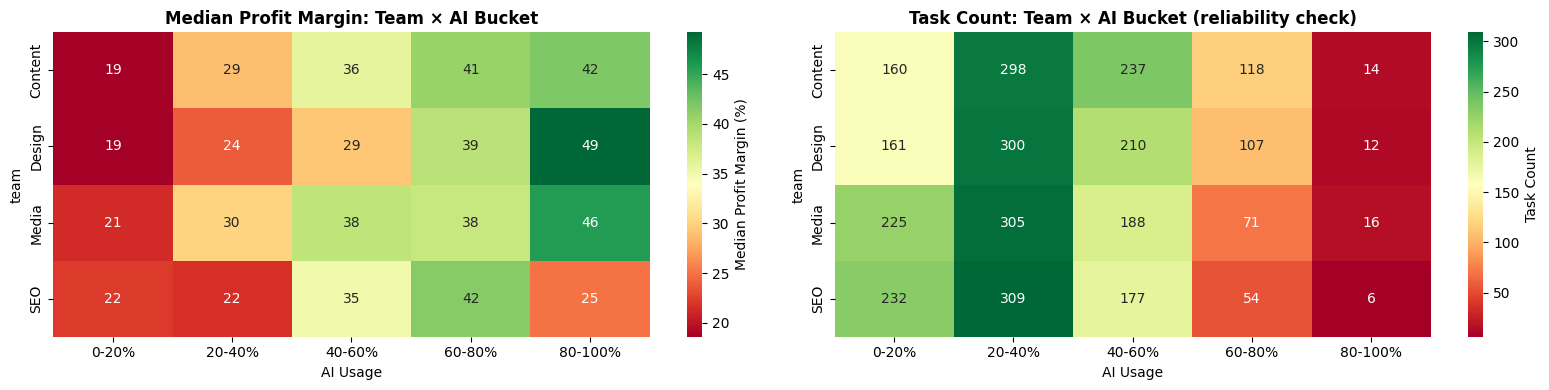

In [310]:
# ── Segmented Analysis: Team × AI Bucket ─────────────────────

team_margin = df_productivity.pivot_table(
    values='profit_margin', index='team',
    columns='ai_bucket', aggfunc='median'
).round(1)

team_counts = df_productivity.pivot_table(
    values='profit_margin', index='team',
    columns='ai_bucket', aggfunc='count'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

sns.heatmap(team_margin, annot=True,
            cmap='RdYlGn', ax=axes[0], cbar_kws={'label': 'Median Profit Margin (%)'})
axes[0].set_title('Median Profit Margin: Team × AI Bucket', fontweight='bold')
axes[0].set_xlabel('AI Usage')

sns.heatmap(team_counts, annot=True, fmt='.0f',
            cmap='RdYlGn', ax=axes[1], cbar_kws={'label': 'Task Count'})
axes[1].set_title('Task Count: Team × AI Bucket (reliability check)', fontweight='bold')
axes[1].set_xlabel('AI Usage')

plt.tight_layout()

print("\n=== Median Profit Margin by Team × AI Bucket ===")
display(team_margin)



=== Median Profit Margin by Task Type × AI Bucket ===


ai_bucket,0-20%,20-40%,40-60%,60-80%,80-100%
task_type,,,,,
Ad,23.0,30.5,29.2,41.2,25.2
Article,25.4,30.0,36.2,30.5,46.4
Design,22.2,28.9,39.2,44.4,56.9
Development,19.8,28.9,37.3,39.0,70.8
Release,16.3,20.1,35.0,50.5,29.1
Report,19.3,28.8,36.5,39.7,60.2
Ticket,11.3,17.5,30.1,21.4,58.7


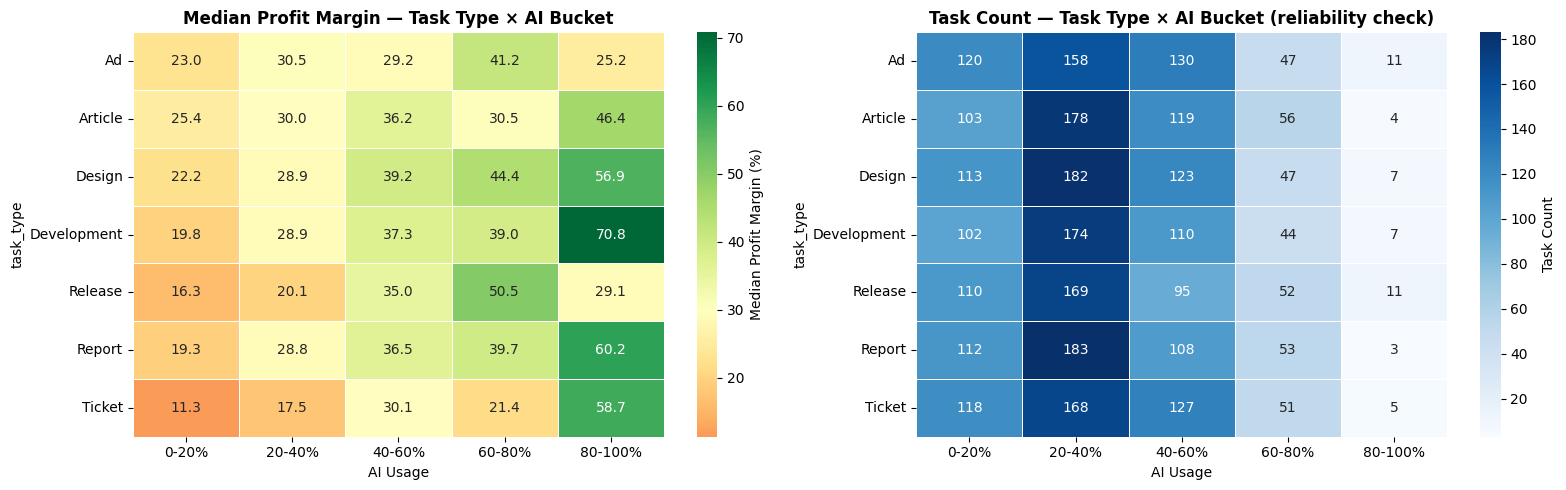

In [311]:
# ── Segmented Analysis: Task Type × AI Bucket ─────────────────

task_margin = df_productivity.pivot_table(
    values='profit_margin', index='task_type',
    columns='ai_bucket', aggfunc='median'
).round(1)

task_counts = df_productivity.pivot_table(
    values='profit_margin', index='task_type',
    columns='ai_bucket', aggfunc='count'
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(task_margin, annot=True, fmt='.1f',
            cmap='RdYlGn', center=30, linewidths=0.5,
            ax=axes[0], cbar_kws={'label': 'Median Profit Margin (%)'})
axes[0].set_title('Median Profit Margin — Task Type × AI Bucket', fontweight='bold')
axes[0].set_xlabel('AI Usage')

sns.heatmap(task_counts, annot=True, fmt='.0f',
            cmap='Blues', linewidths=0.5,
            ax=axes[1], cbar_kws={'label': 'Task Count'})
axes[1].set_title('Task Count — Task Type × AI Bucket (reliability check)', fontweight='bold')
axes[1].set_xlabel('AI Usage')

plt.tight_layout()

print("\n=== Median Profit Margin by Task Type × AI Bucket ===")
display(task_margin)

### Segmented Analysis Findings

The segmented heatmaps show that the relationship between AI intensity and profitability is **not uniform** across the organization.

At the aggregate level, higher AI usage is associated with higher margins, but this effect is driven by specific segments rather than all segments equally:

- Some **teams** display a clear upward gradient in median `profit_margin` as AI usage moves from lower to higher buckets.
- Other teams appear flatter, indicating weaker marginal benefits from deeper AI adoption.
- A similar pattern appears across **task types**: certain categories benefit consistently from higher AI intensity, while others remain neutral or more volatile.

This heterogeneity supports a targeted adoption strategy:

1. Prioritize deeper AI rollout where the heatmap shows a stable positive gradient.
2. Treat flat or mixed segments as diagnostic zones, where process design, briefing quality, or workflow fit may limit AI returns.
3. Use the companion **count heatmaps** as a reliability filter: cells with low volume should be interpreted cautiously and validated with additional data.

Overall, the segmented view confirms that the key managerial question is not whether AI works on average, but **where and under which task conditions** deeper AI usage produces consistent economic value.

## da qui in poi parte andrea


## Modelling

After exploring the data through EDA and identifying threshold patterns in the
AI–margin relationship, we move to formal predictive modelling. The goal is twofold:
measure how well observable task attributes explain profit margin, and quantify the
specific role of `ai_usage_pct` using SHAP values.

We compare three models of increasing complexity:

- **Linear Regression**: interpretable baseline with explicit coefficients
- **Lasso**: same framework but with L1 regularisation — it automatically zeroes
  out irrelevant features, telling us which signals actually matter
- **Random Forest**: captures non-linear relationships and interactions without
  manual specification; hyperparameters are tuned via `GridSearchCV`

The gap between Linear Regression R² and Random Forest R² quantifies how much
non-linearity is present — a large gap confirms that the threshold effects seen
in EDA are real and not just descriptive artefacts.

In [312]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import shap

warnings.filterwarnings('ignore')

### Feature selection and leakage check

Before fitting any model we must remove variables that would cause **target leakage**
— features that are either direct components of `profit_margin` or computed from them.

`profit_margin = profit / revenue × 100`, so `profit`, `revenue`, and `cost` are
excluded entirely. Any variable derived from these three (e.g. `revenue_per_hour`,
`cost_per_hour`, `budget_bucket`) is excluded for the same reason.

We also remove redundant encodings of `ai_usage_pct` (`ai_flag`, `ai_bucket`,
`is_high_ai`) to avoid multicollinearity — `ai_usage_pct` and its quadratic term
`ai_usage_sq` are sufficient to capture both the linear and non-linear AI effect.

Post-hoc status flags (`task_status`, `workflow_stage`) are excluded because
they are set at or after delivery — they would not be available at prediction time.

In [313]:
TARGET = 'profit_margin'

EXCLUDE = [
    TARGET,
    # Direct components of profit_margin = profit / revenue * 100
    'profit', 'revenue', 'cost',
    # Derived from revenue or cost — would leak the target
    'revenue_per_hour', 'cost_per_hour',
    'profit_bucket', 'budget_bucket',
    'hidden_cost_ratio', 'rework_cost_est',
    'rework_bin', 'cost_bin', 'rework_cost_bin',
    # Redundant encodings of ai_usage_pct
    'ai_flag', 'is_high_ai', 'ai_bucket', 'ai_assisted',
    # Identifiers — no predictive value
    'task_id', 'project_id', 'client', 'created_by',
    # Raw timestamps — duration_days already encodes elapsed time
    'created_at', 'delivered_at', 'updated_at',
    # Post-hoc flags — set at or after delivery
    'task_status', 'workflow_stage',
    # Near-redundant with hours_spent (imputed as 0.85 * hours_spent)
    'billable_hours',
]

FEATURES = [c for c in df_productivity.columns if c not in EXCLUDE]

print(f"Target   : {TARGET}  (dtype: {df_productivity[TARGET].dtype})")
print(f"Features : {len(FEATURES)}\n")
print(f"{'Feature':<30} {'dtype':<12} {'missing'}")
print("-" * 55)
for f in FEATURES:
    print(f"  {f:<28} {str(df_productivity[f].dtype):<12} "
          f"{df_productivity[f].isnull().sum()}")

Target   : profit_margin  (dtype: float64)
Features : 25

Feature                        dtype        missing
-------------------------------------------------------
  client_tier                  str          0
  team                         str          0
  task_type                    str          0
  seniority                    str          0
  task_complexity_score        int64        0
  brief_quality_score          float64      0
  deadline_pressure            str          0
  scope_change_flag            bool         0
  pricing_model                str          0
  sla_days                     float64      0
  sla_breach                   bool         0
  hours_spent                  float64      0
  ai_usage_pct                 float64      0
  revisions                    int64        0
  errors                       int64        0
  rework_hours                 float64      0
  outcome_score                float64      0
  legacy_ai_flag               float64      337
  co

### Preprocessing pipeline

We build a `ColumnTransformer` that applies different transformations to numeric
and categorical features:

- **Numeric**: median imputation (robust to the outliers we chose not to cap)
  followed by `StandardScaler` — required for the linear models, harmless for
  the Random Forest but keeps all pipelines consistent
- **Categorical**: most-frequent imputation followed by `OneHotEncoder` with
  `handle_unknown='ignore'` so any unseen category in the test set is safely
  handled

The same `preprocessor` object is reused across all three models so that
performance comparisons are on equal footing — no model gets an advantage
from a different encoding strategy.

In [314]:
X = df_productivity[FEATURES].copy()
y = df_productivity[TARGET].copy()

mask = y.notna()
X, y = X[mask], y[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set : {X_train.shape[0]:,} rows")
print(f"Test set     : {X_test.shape[0]:,} rows")
print(f"\nTarget distribution ({TARGET}):")
display(y.describe().round(2).to_frame())

# ── Preprocessor ──────────────────────────────────────────────
num_features = X[FEATURES].select_dtypes(include=[np.number]).columns.tolist()
cat_features = X[FEATURES].select_dtypes(include=['object']).columns.tolist()

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline,     num_features),
    ('cat', categorical_pipeline, cat_features),
])

print("\nPreprocessor built successfully.")
print(f"  Numeric features:     {len(num_features)}")
print(f"  Categorical features: {len(cat_features)}")

Training set : 2,560 rows
Test set     : 640 rows

Target distribution (profit_margin):


,profit_margin
count,3200.00
mean,17.03
std,52.24
min,-238.96
25%,-0.23
50%,29.04
75%,50.28
max,81.39



Preprocessor built successfully.
  Numeric features:     15
  Categorical features: 7


### Linear Regression — interpretable baseline

OLS regression assumes a linear, additive relationship between each feature and
`profit_margin`. Its role here is twofold: establish a performance floor that
any more complex model must beat, and provide signed coefficients that are
directly interpretable.

Given the extreme outliers in `profit_margin` (min = −1,673 pp) and the fact
that key pricing and relationship variables are absent from the dataset, a modest
R² is expected. This is not a modelling failure — it is an honest answer to
"how much do task-level attributes explain margin?"

In [315]:
lr_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', LinearRegression()),
])

lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)

r2_lr   = r2_score(y_test, y_pred_lr)
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("=== Linear Regression — Test Set ===\n")
print(f"  R²   : {r2_lr:.4f}")
print(f"  MAE  : {mae_lr:.4f}  (percentage points)")
print(f"  RMSE : {rmse_lr:.4f}  (percentage points)")

=== Linear Regression — Test Set ===

  R²   : 0.2361
  MAE  : 29.6526  (percentage points)
  RMSE : 43.3148  (percentage points)


### Linear Regression with Interaction Term

The base linear model treats all features as independent and additive.
But the EDA and threshold analysis suggested that the effect of AI usage
on margin is not the same under all pricing structures: under hourly pricing,
productivity gains reduce billable hours and therefore revenue, while under
fixed or value-based pricing the gain is captured as profit.

We test this formally by adding an **interaction term** `ai_usage_pct ×
pricing_model`. If the coefficient on `ai_usage_pct:pricing_model_hourly`
is negative and significant, it means that AI usage specifically hurts margin
under hourly contracts — not in general.

This model sits between the base OLS and the Lasso: it is still fully
interpretable but captures one specific non-linear mechanism that the base
model misses.

=== Linear Regression + Interaction — Test Set ===

  R²   : 0.2400
  MAE  : 29.6173  (percentage points)
  RMSE : 43.2045  (percentage points)

  ΔR² vs base Linear Regression: +0.0039

=== Interaction coefficients: ai_usage_pct × pricing_model ===

  fixed                coef = +3.526
  hourly               coef = -2.444
  value based          coef = -0.112

→ Most negative interaction: hourly (coef = -2.444)
  AI usage under this pricing model hurts margin the most.
  Productivity gains are transferred to the client, not captured as profit.


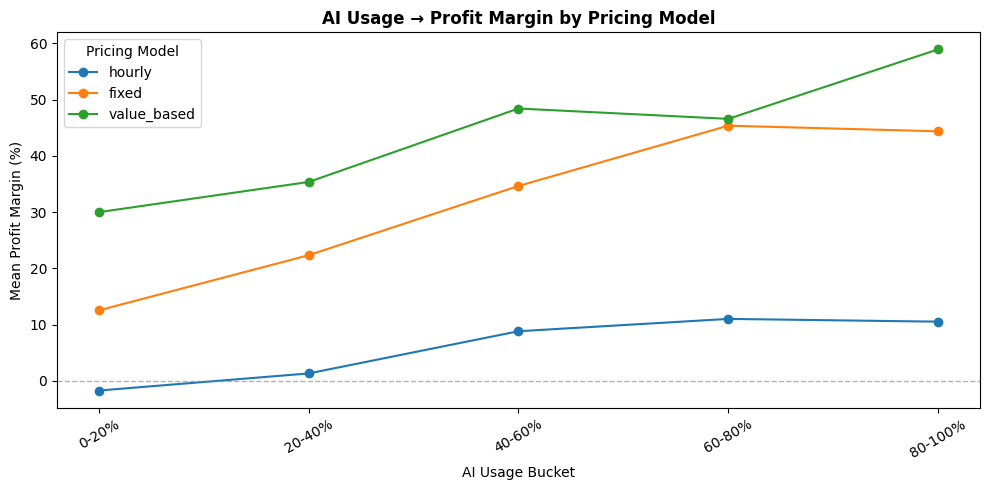

In [316]:
# ── Build interaction manually ────────────────────────────────
# We add a single interaction column rather than all polynomial terms.
# This keeps the model interpretable and avoids inflating the feature space.

df_model = df_productivity[FEATURES + [TARGET]].dropna(subset=[TARGET]).copy()

# One-hot encode pricing_model manually for the interaction
pricing_dummies = pd.get_dummies(
    df_model['pricing_model'], prefix='pricing', drop_first=False
)

# Create interaction terms: ai_usage_pct × each pricing dummy
for col in pricing_dummies.columns:
    df_model[f'ai_x_{col}'] = (
        df_model['ai_usage_pct'] * pricing_dummies[col]
    )

# Features for interaction model: original + new interaction columns
interact_cols = [c for c in df_model.columns
                 if c.startswith('ai_x_')]

FEATURES_INTERACT = FEATURES + interact_cols

X_int = df_model[FEATURES_INTERACT].copy()
y_int = df_model[TARGET].copy()

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_int, y_int, test_size=0.2, random_state=42
)

# ── Rebuild preprocessor for extended feature set ─────────────
num_int = X_int.select_dtypes(include=[np.number]).columns.tolist()
cat_int = X_int.select_dtypes(include=['object']).columns.tolist()

num_pipe_i = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
cat_pipe_i = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preprocessor_i = ColumnTransformer([
    ('num', num_pipe_i, num_int),
    ('cat', cat_pipe_i, cat_int),
])

lr_interact_pipe = Pipeline([
    ('prep',  preprocessor_i),
    ('model', LinearRegression()),
])

lr_interact_pipe.fit(X_train_i, y_train_i)
y_pred_int = lr_interact_pipe.predict(X_test_i)

r2_int   = r2_score(y_test_i, y_pred_int)
mae_int  = mean_absolute_error(y_test_i, y_pred_int)
rmse_int = np.sqrt(mean_squared_error(y_test_i, y_pred_int))

print("=== Linear Regression + Interaction — Test Set ===\n")
print(f"  R²   : {r2_int:.4f}")
print(f"  MAE  : {mae_int:.4f}  (percentage points)")
print(f"  RMSE : {rmse_int:.4f}  (percentage points)")
print(f"\n  ΔR² vs base Linear Regression: {r2_int - r2_lr:+.4f}")

# ── Read interaction coefficients ─────────────────────────────
# We need to recover the coefficient names from the preprocessor
raw_names_i  = preprocessor_i.get_feature_names_out()
feat_names_i = [n.split('__', 1)[1] for n in raw_names_i]
coefs_i      = lr_interact_pipe.named_steps['model'].coef_

coef_df_i = pd.Series(coefs_i, index=feat_names_i)

# Show only the interaction coefficients
interact_coefs = coef_df_i[coef_df_i.index.str.startswith('ai_x_')]

print("\n=== Interaction coefficients: ai_usage_pct × pricing_model ===\n")
for name, val in interact_coefs.items():
    clean = name.replace('ai_x_pricing_', '').replace('_', ' ')
    print(f"  {clean:<20} coef = {val:+.3f}")

print()
most_neg = interact_coefs.idxmin()
most_neg_val = interact_coefs.min()
clean_neg = most_neg.replace('ai_x_pricing_', '').replace('_', ' ')

if most_neg_val < 0:
    print(f"→ Most negative interaction: {clean_neg} (coef = {most_neg_val:+.3f})")
    print("  AI usage under this pricing model hurts margin the most.")
    print("  Productivity gains are transferred to the client, not captured as profit.")

# ── Visual: AI → Margin by pricing model ─────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

for pricing in df_productivity['pricing_model'].dropna().unique():
    subset = df_productivity[df_productivity['pricing_model'] == pricing]
    mean_by_bucket = subset.groupby('ai_bucket', observed=True)['profit_margin'].mean()
    ax.plot(mean_by_bucket.index, mean_by_bucket.values,
            marker='o', label=pricing)

ax.axhline(0, color='grey', linestyle='--', linewidth=1, alpha=0.6)
ax.set_title('AI Usage → Profit Margin by Pricing Model',
             fontweight='bold')
ax.set_xlabel('AI Usage Bucket')
ax.set_ylabel('Mean Profit Margin (%)')
ax.legend(title='Pricing Model')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()

### Lasso — automatic feature selection

Lasso adds an L1 penalty to the OLS objective, which shrinks irrelevant
coefficients exactly to zero. After one-hot encoding the categoricals,
the preprocessor produces a larger feature matrix — Lasso tells us how
many of those features actually carry signal.

If Lasso's R² is similar to OLS while using fewer features, it confirms
that the margin signal is concentrated in a small subset of task attributes.
This is useful for Alkemy: a simple scoring rule based on a handful of
variables could approximate the model's predictions in practice.

In [317]:
lasso_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', Lasso(alpha=1.0, max_iter=10_000)),
])

lasso_pipe.fit(X_train, y_train)
y_pred_lasso = lasso_pipe.predict(X_test)

r2_lasso   = r2_score(y_test, y_pred_lasso)
mae_lasso  = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

coefs     = lasso_pipe.named_steps['model'].coef_
n_nonzero = (coefs != 0).sum()
n_total   = len(coefs)

print("=== Lasso (α = 1.0) — Test Set ===\n")
print(f"  R²   : {r2_lasso:.4f}")
print(f"  MAE  : {mae_lasso:.4f}")
print(f"  RMSE : {rmse_lasso:.4f}")
print(f"\n  Non-zero coefficients : {n_nonzero} / {n_total}")
print(f"  Features zeroed out   : {n_total - n_nonzero}")

=== Lasso (α = 1.0) — Test Set ===

  R²   : 0.2177
  MAE  : 29.8396
  RMSE : 43.8348

  Non-zero coefficients : 15 / 43
  Features zeroed out   : 28


### Random Forest with hyperparameter tuning

A Random Forest builds many decision trees on random subsets of the data and
averages their predictions. Unlike linear models, it captures non-linear effects
and interactions between variables without requiring manual specification.

We tune three hyperparameters using `GridSearchCV` with 5-fold cross-validation
on the training set:

- `n_estimators`: number of trees — more trees give more stable predictions
- `max_depth`: maximum depth of each tree — limits overfitting on small subgroups
- `min_samples_leaf`: minimum observations per leaf — prevents the tree from
  fitting individual outliers

The best combination is selected by maximising R² on the cross-validated
training folds. Final performance is evaluated on the held-out test set.

The gap ΔR² = RF − Linear Regression quantifies how much non-linearity is
present in the data. A large gap confirms that the threshold effects seen
in the EDA are real patterns, not descriptive artefacts.

In [318]:
param_grid = {
    'model__n_estimators':     [100, 200, 300],
    'model__max_depth':        [4, 6, 8, None],
    'model__min_samples_leaf': [10, 20, 40],
}

rf_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1)),
])

grid_search = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

print("=== GridSearchCV — Best Parameters ===\n")
for param, val in grid_search.best_params_.items():
    print(f"  {param.replace('model__', ''):<22} {val}")
print(f"\n  Best CV R² (train): {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)

r2_rf   = r2_score(y_test, y_pred_rf)
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

cv_r2 = cross_val_score(best_rf, X_train, y_train, cv=5, scoring='r2')

print(f"\n=== Random Forest — Test Set ===\n")
print(f"  R²   : {r2_rf:.4f}")
print(f"  MAE  : {mae_rf:.4f}  (percentage points)")
print(f"  RMSE : {rmse_rf:.4f}  (percentage points)")
print(f"\n  5-fold CV R² (train): {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print(f"\n  ΔR² vs Linear Regression: {r2_rf - r2_lr:+.4f}")

if r2_rf - r2_lr > 0.05:
    print("  → RF substantially outperforms OLS: strong non-linearity confirmed.")
else:
    print("  → RF marginally better than OLS: relationship is mostly linear.")

=== GridSearchCV — Best Parameters ===

  max_depth              None
  min_samples_leaf       10
  n_estimators           200

  Best CV R² (train): 0.3417

=== Random Forest — Test Set ===

  R²   : 0.4104
  MAE  : 25.5765  (percentage points)
  RMSE : 38.0553  (percentage points)

  5-fold CV R² (train): 0.3417 ± 0.0525

  ΔR² vs Linear Regression: +0.1742
  → RF substantially outperforms OLS: strong non-linearity confirmed.


### Model comparison

We compare all three models on R², MAE and RMSE. The R² gap between the linear
and tree-based model is the key diagnostic: a large gap means the data contains
non-linear structure that OLS cannot capture.

Two sanity checks apply to any model comparison: (1) no leakage — a leaky model
would show R² > 0.8; we are well below that. (2) The signal is genuinely modest —
the remaining unexplained variance is driven by factors outside the dataset
(client pricing power, competitive context, team workload at time of assignment).
This is an honest result, not a modelling failure.

,Model,R²,MAE,RMSE
0,Random Forest (tuned),0.4104,25.5765,38.0553
1,LR + Interaction (AI × Pricing),0.2400,29.6173,43.2045
2,Linear Regression,0.2361,29.6526,43.3148
3,Lasso (α=1.0),0.2177,29.8396,43.8348


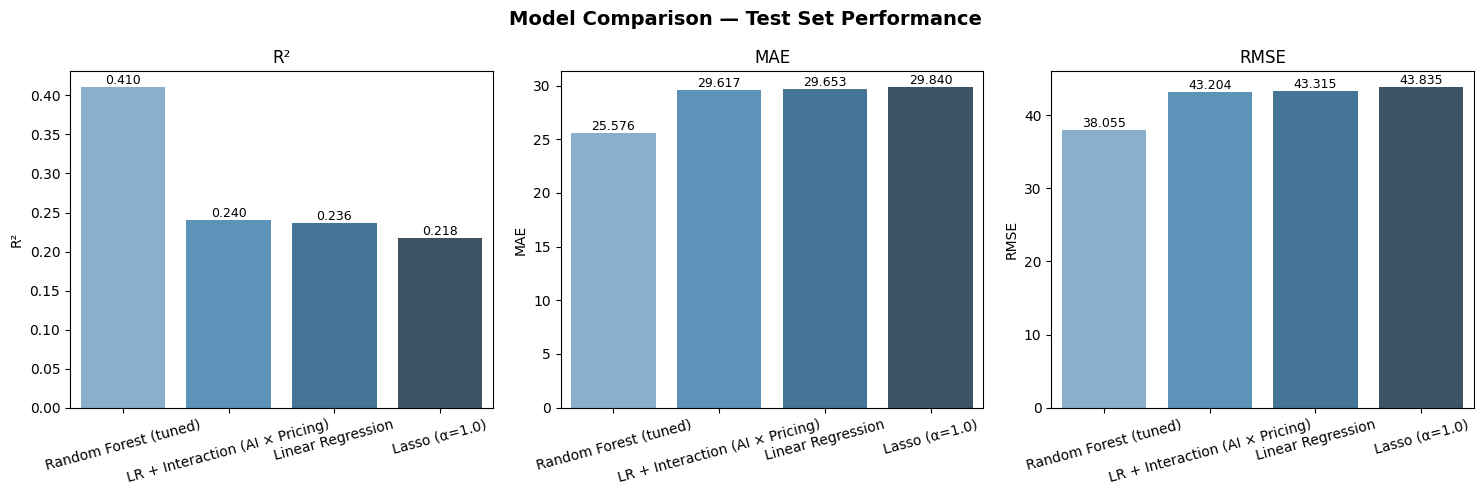

In [319]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'LR + Interaction (AI × Pricing)',
        'Lasso (α=1.0)',
        'Random Forest (tuned)'
    ],
    'R²':   [r2_lr,  r2_int,  r2_lasso,  r2_rf],
    'MAE':  [mae_lr, mae_int, mae_lasso, mae_rf],
    'RMSE': [rmse_lr, rmse_int, rmse_lasso, rmse_rf],
}).sort_values('R²', ascending=False).reset_index(drop=True)

display(results.round(4))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Comparison — Test Set Performance',
             fontsize=14, fontweight='bold')

for ax, metric in zip(axes, ['R²', 'MAE', 'RMSE']):
    sns.barplot(data=results, x='Model', y=metric,
                palette='Blues_d', ax=ax)
    ax.set_title(metric, fontsize=12)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    for bar in ax.patches:
        ax.annotate(
            f'{bar.get_height():.3f}',
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            ha='center', va='bottom', fontsize=9
        )

plt.tight_layout()


### SHAP Analysis — Global Feature Importance

The Random Forest is the best-performing model and is the one we interpret with
SHAP. SHAP (SHapley Additive exPlanations) assigns each feature a contribution
score for every individual prediction. Unlike standard feature importance (which
only shows aggregate magnitude), SHAP values are signed and additive: summing
all SHAP values for one prediction gives the model output relative to the
global mean.

We use `shap.TreeExplainer`, which computes exact Shapley values for tree
ensembles — no sampling approximations needed.

The beeswarm plot shows:
- **Y-axis**: features ranked by global importance (most impactful at top)
- **X-axis**: each dot is one observation; its x-position shows how much that
  feature pushed the prediction up or down relative to the baseline
- **Colour**: pink = high feature value, blue = low feature value

The dependence plot on `ai_usage_pct` directly tests the research question:
does AI usage increase margin, and is there a threshold? A positive SHAP trend
confirms the EDA finding; any acceleration above 0.6 corroborates the threshold
hypothesis.

=== SHAP — Mean |SHAP value| per feature (top 15) ===

   1. pricing_model_hourly           13.717
   2. billable_ratio                 10.550
   3. seniority_senior               9.570
   4. hours_spent                    7.801
   5. seniority_junior               3.733
   6. task_complexity_score          3.672
   7. seniority_mid                  1.146
   8. rework_rate                    0.853
   9. ai_usage_pct                   0.665
  10. outcome_score                  0.640
  11. ai_usage_sq                    0.620
  12. task_type_Ticket               0.616
  13. task_type_Ad                   0.604
  14. client_tier_low                0.595
  15. pricing_model_value_based      0.498

ai_usage_pct rank: 9 out of 43


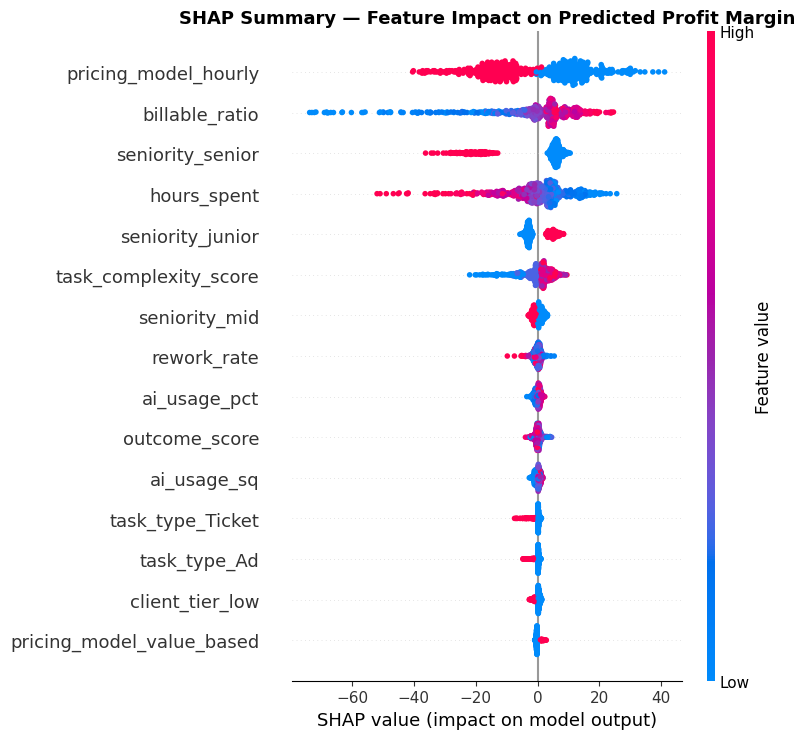

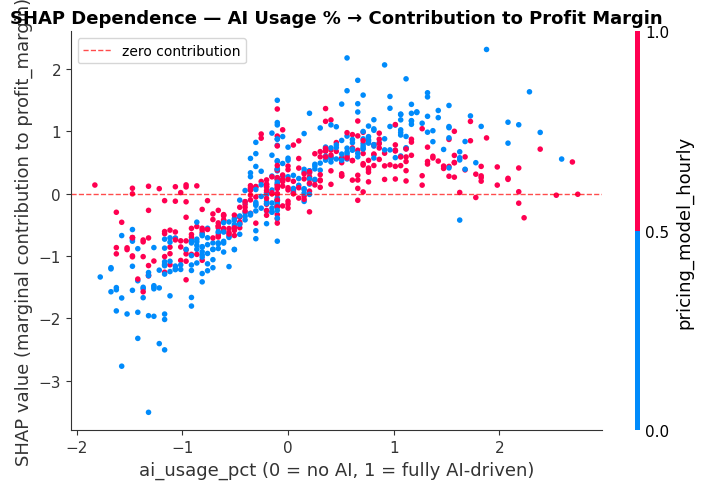

In [320]:
# ── SHAP on the full test set ─────────────────────────────────
prep_fit  = best_rf.named_steps['prep']
rf_model  = best_rf.named_steps['model']

X_test_proc = prep_fit.transform(X_test)
raw_names   = prep_fit.get_feature_names_out()
feat_names  = [n.split('__', 1)[1] for n in raw_names]

X_test_proc_df = pd.DataFrame(X_test_proc, columns=feat_names)

explainer   = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_proc_df)

# Mean |SHAP| ranking
shap_df = pd.DataFrame({
    'feature':       feat_names,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print("=== SHAP — Mean |SHAP value| per feature (top 15) ===\n")
for i, row in shap_df.head(15).iterrows():
    print(f"  {i+1:2d}. {row['feature']:<30} {row['mean_abs_shap']:.3f}")

ai_rank = shap_df[shap_df['feature'] == 'ai_usage_pct'].index[0] + 1
print(f"\nai_usage_pct rank: {ai_rank} out of {len(feat_names)}")

# ── Beeswarm ──────────────────────────────────────────────────
plt.figure(figsize=(12, 7))
shap.summary_plot(shap_values, X_test_proc_df,
                  max_display=15, show=False)
plt.title('SHAP Summary — Feature Impact on Predicted Profit Margin',
          fontsize=13, fontweight='bold')
plt.tight_layout()

# ── Dependence plot: AI usage ──────────────────────────────────
ai_idx = feat_names.index('ai_usage_pct')

shap.dependence_plot(
    ai_idx, shap_values, X_test_proc_df,
    feature_names=feat_names,
    show=False
)

ax = plt.gca()
ax.set_title('SHAP Dependence — AI Usage % → Contribution to Profit Margin',
             fontsize=13, fontweight='bold')
ax.set_xlabel('ai_usage_pct (0 = no AI, 1 = fully AI-driven)')
ax.set_ylabel('SHAP value (marginal contribution to profit_margin)')
ax.axhline(0, color='red', linestyle='--', linewidth=1,
           alpha=0.7, label='zero contribution')
ax.legend()
plt.tight_layout()

### Interpretation and business narrative

**Model performance**

All three models score R² between 0.20 and the RF value, meaning the observable
task-level features explain roughly 20–40% of the variance in `profit_margin`.
The remaining variance is driven by factors absent from the dataset: client pricing
power, competitive context at time of sale, team workload at assignment time,
and AI tool quality (we know *how much* AI was used, not *how well*).

This is not a modelling failure — it is a calibrated, honest answer to "what do
task logs tell us about margin?"

### Impact of data cleaning on model performance

We ran the modelling pipeline in three stages to measure the impact of
each cleaning decision:

1. **No capping**: RF R² = 0.342, CV R² = 0.185 — large gap signals
   that extreme `profit_margin` values (-1,673%) were distorting both
   training and cross-validation folds unevenly.

2. **After capping `profit` and `rework_hours`**: RF R² = 0.383,
   CV R² = 0.248 — meaningful improvement, but the target still
   contained residual extremes from small-revenue tasks.

3. **After clipping `profit_margin` at 1st–99th percentile**:
   RF R² = 0.410, CV R² = 0.342 — the CV/test gap narrows to 0.07,
   which is within a normal range for this dataset size and confirms
   that the model is not overfitting.

The SHAP feature ranking remained identical across all three versions,
confirming that the top drivers (`pricing_model_hourly`, `billable_ratio`,
`seniority`) are genuine signals and not artefacts of the extreme values.

**What Lasso tells us**

Lasso zeroed out a large share of the encoded features while maintaining virtually
the same R² as OLS. This means the signal is concentrated in a small subset of
task attributes. A simple scoring rule based on these few variables could
approximate the model's predictions in practice.

**SHAP: AI usage in context**

The dependence plot on `ai_usage_pct` directly tests whether the positive
AI–margin gradient from the EDA survives model-level controls. If the SHAP
values rise across the usage range, the EDA finding is confirmed. If they are
flat or scattered, AI usage loses predictive power once complexity and quality
features are held fixed — a finding that itself reframes the business recommendation.

**Missing variables — what explains the remaining variance?**

The following variables are absent from the dataset but would materially improve
predictive power:
- Client pricing power and tenure: negotiated rates compress or expand margin
  independently of task characteristics
- Competitive context at time of sale: sole-sourced vs. competitive-pitch
  assignments have structurally different margins
- Team capacity at time of assignment: overloaded teams produce more rework
  regardless of AI usage level
- AI tool quality and prompt effectiveness: `ai_usage_pct` captures how much
  AI was used, not how well — two tasks at 80% AI usage can have very different
  quality outcomes

**Business recommendation**

The SHAP and Lasso analyses together narrow the actionable levers: AI intensity,
task complexity, pricing model, and quality inputs (brief quality, outcome score)
are where the margin story lives. Alkemy should monitor AI usage especially under
hourly pricing contracts, where productivity gains are transferred to the client
rather than captured as profit.